In [1]:
import arviz as az
import matplotlib.pylab as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz

In [2]:
az.style.use('arviz-grayscale')
from cycler import cycler
default_cycler = cycler(color=['#000000', '#6a6a6a', '#bebebe', '#2a2eec'])
plt.rc('axes', prop_cycle=default_cycler)
plt.rc('figure', dpi=300, figsize=(12, 4))

In [3]:
# Create sample data of 4 coin flips
np.random.seed(123)
trials = 4
theta_real = 0.35
data = pz.Binomial(n=1, p=theta_real).rvs(trials)
data

array([0, 0, 0, 0])

In [4]:
with pm.Model() as our_first_model:
    θ = pm.Beta('θ', alpha=1.0, beta=1.0)
    y = pm.Bernoulli('y', p=θ, observed=data)
    idata = pm.sample(1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [θ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


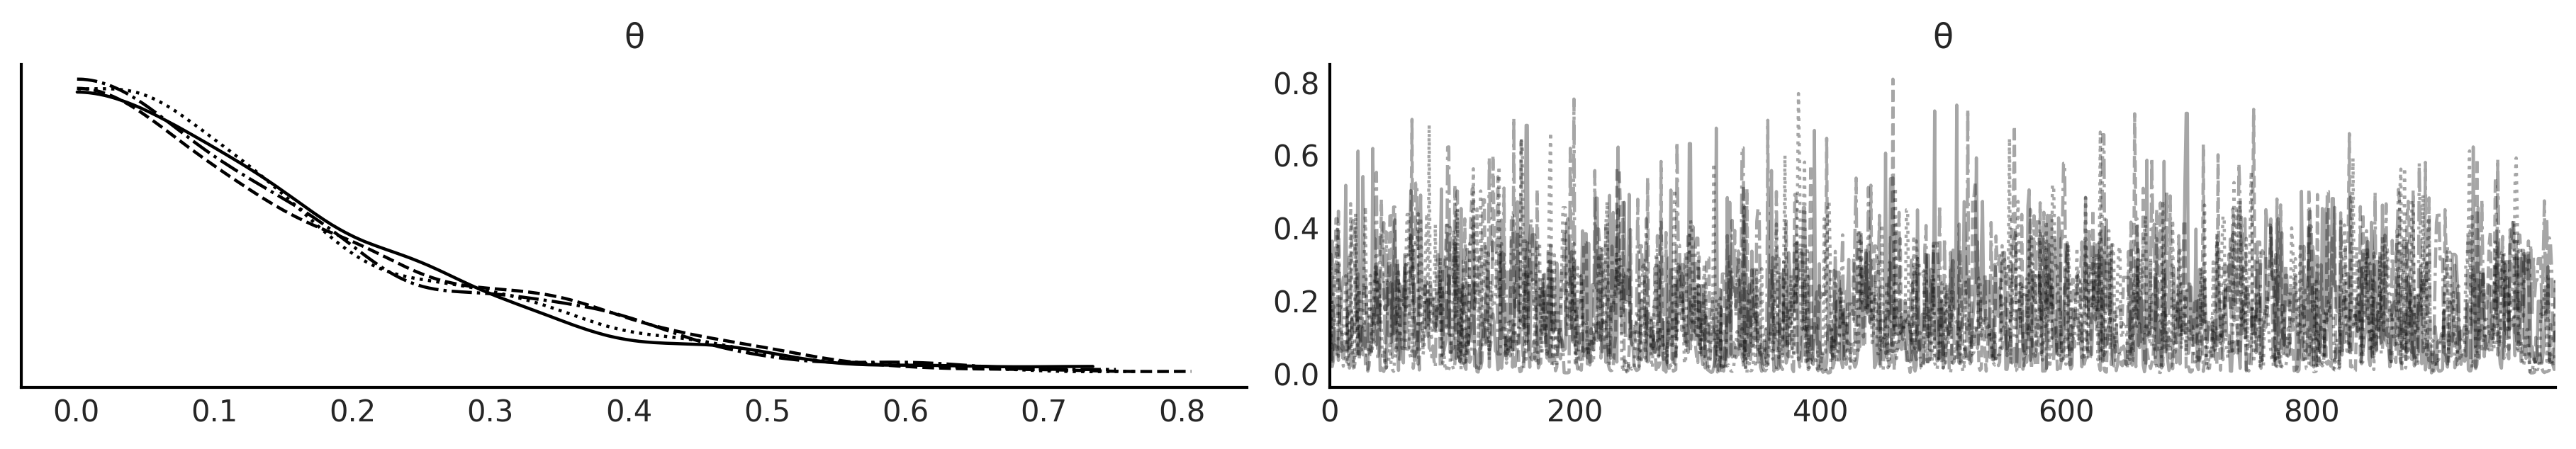

In [5]:
az.plot_trace(idata)
plt.savefig('fig/idata_trace.png')

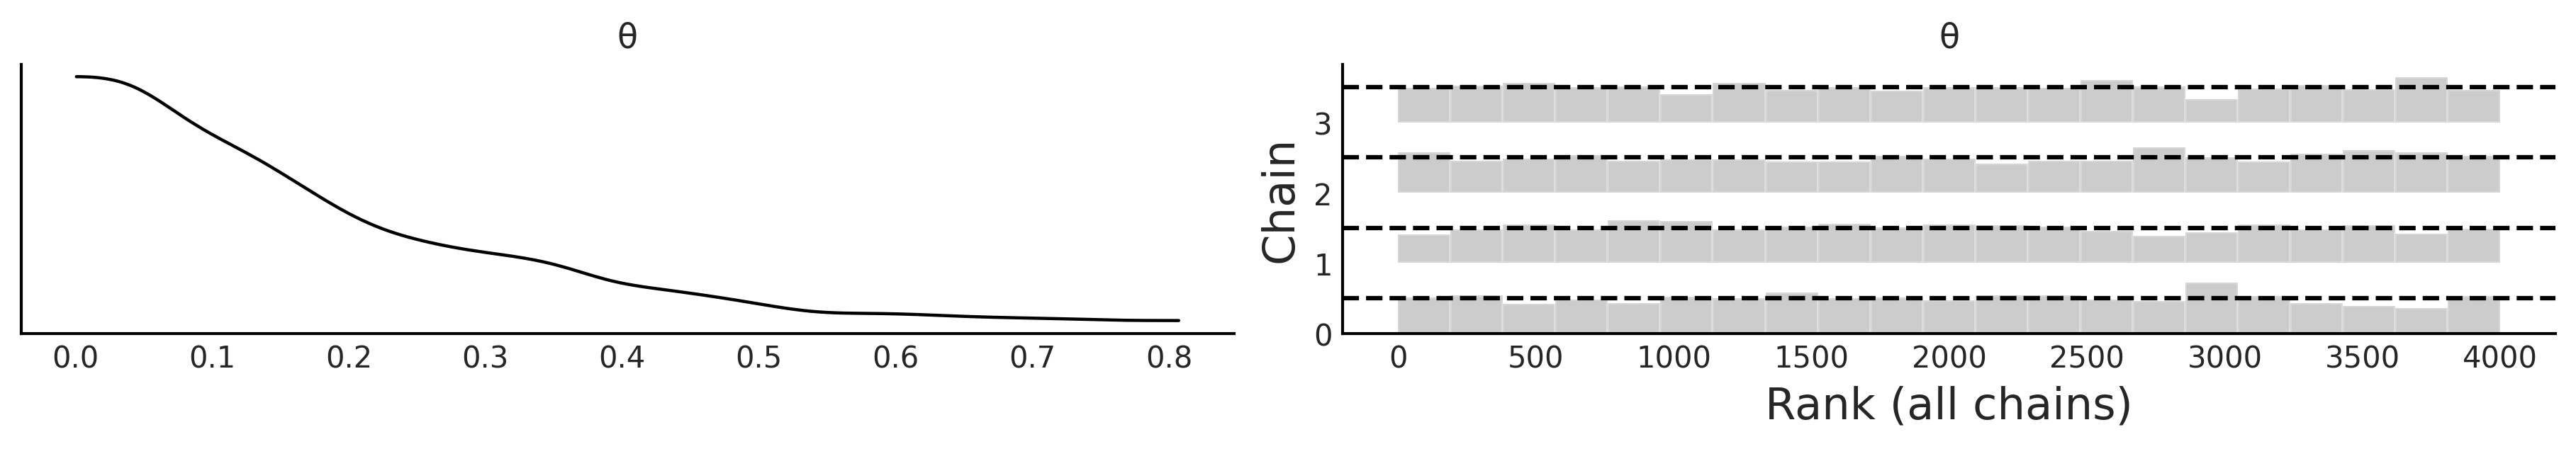

In [6]:
az.plot_trace(idata, kind='rank_bars', combined=True, rank_kwargs={'colors': 'k'})
plt.savefig('fig/idata_rank.png')

In [7]:
az.summary(idata, kind='stats').round(2)

,mean,sd,hdi_3%,hdi_97%
θ,0.17,0.14,0.0,0.43


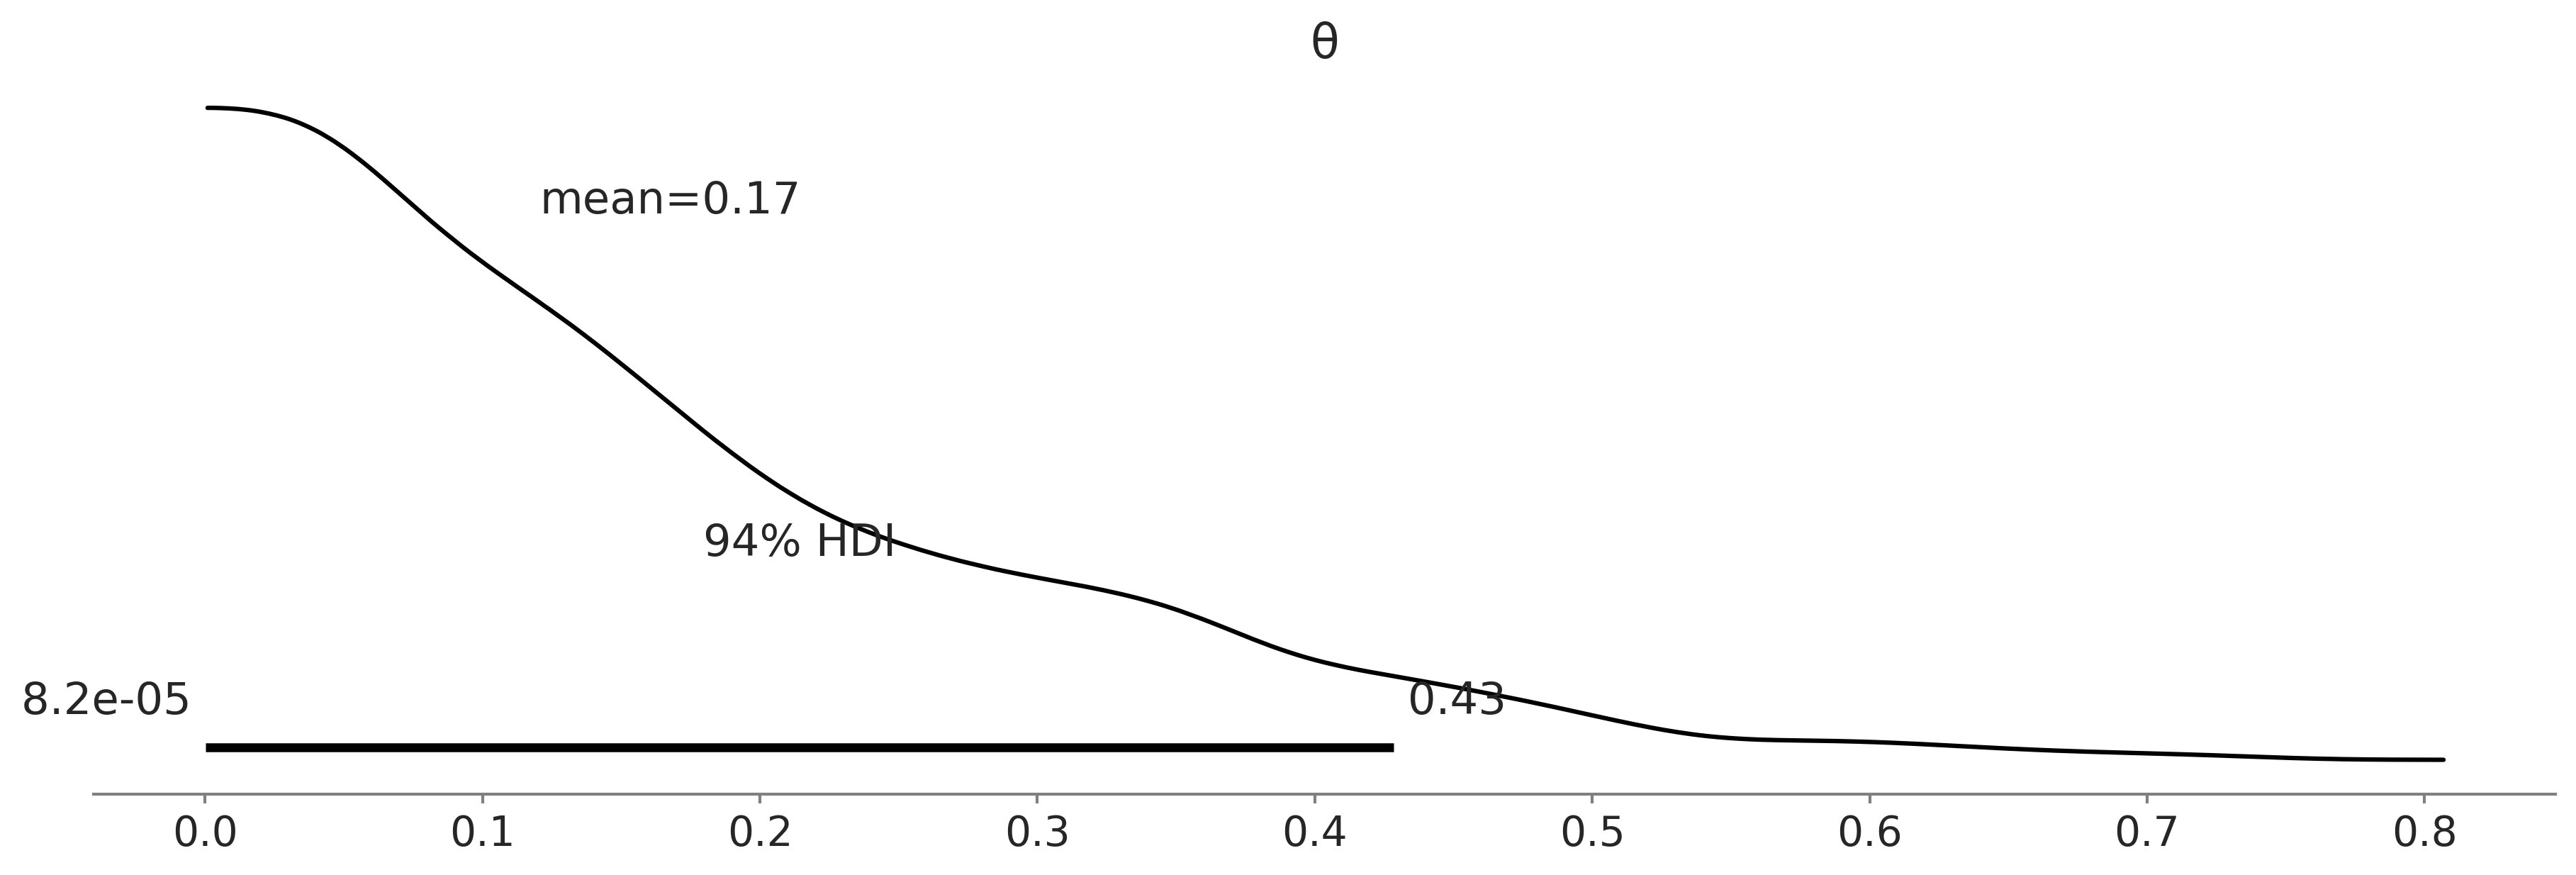

In [8]:
az.plot_posterior(idata, figsize=(12, 4))
plt.savefig('fig/idata_posterior.png')

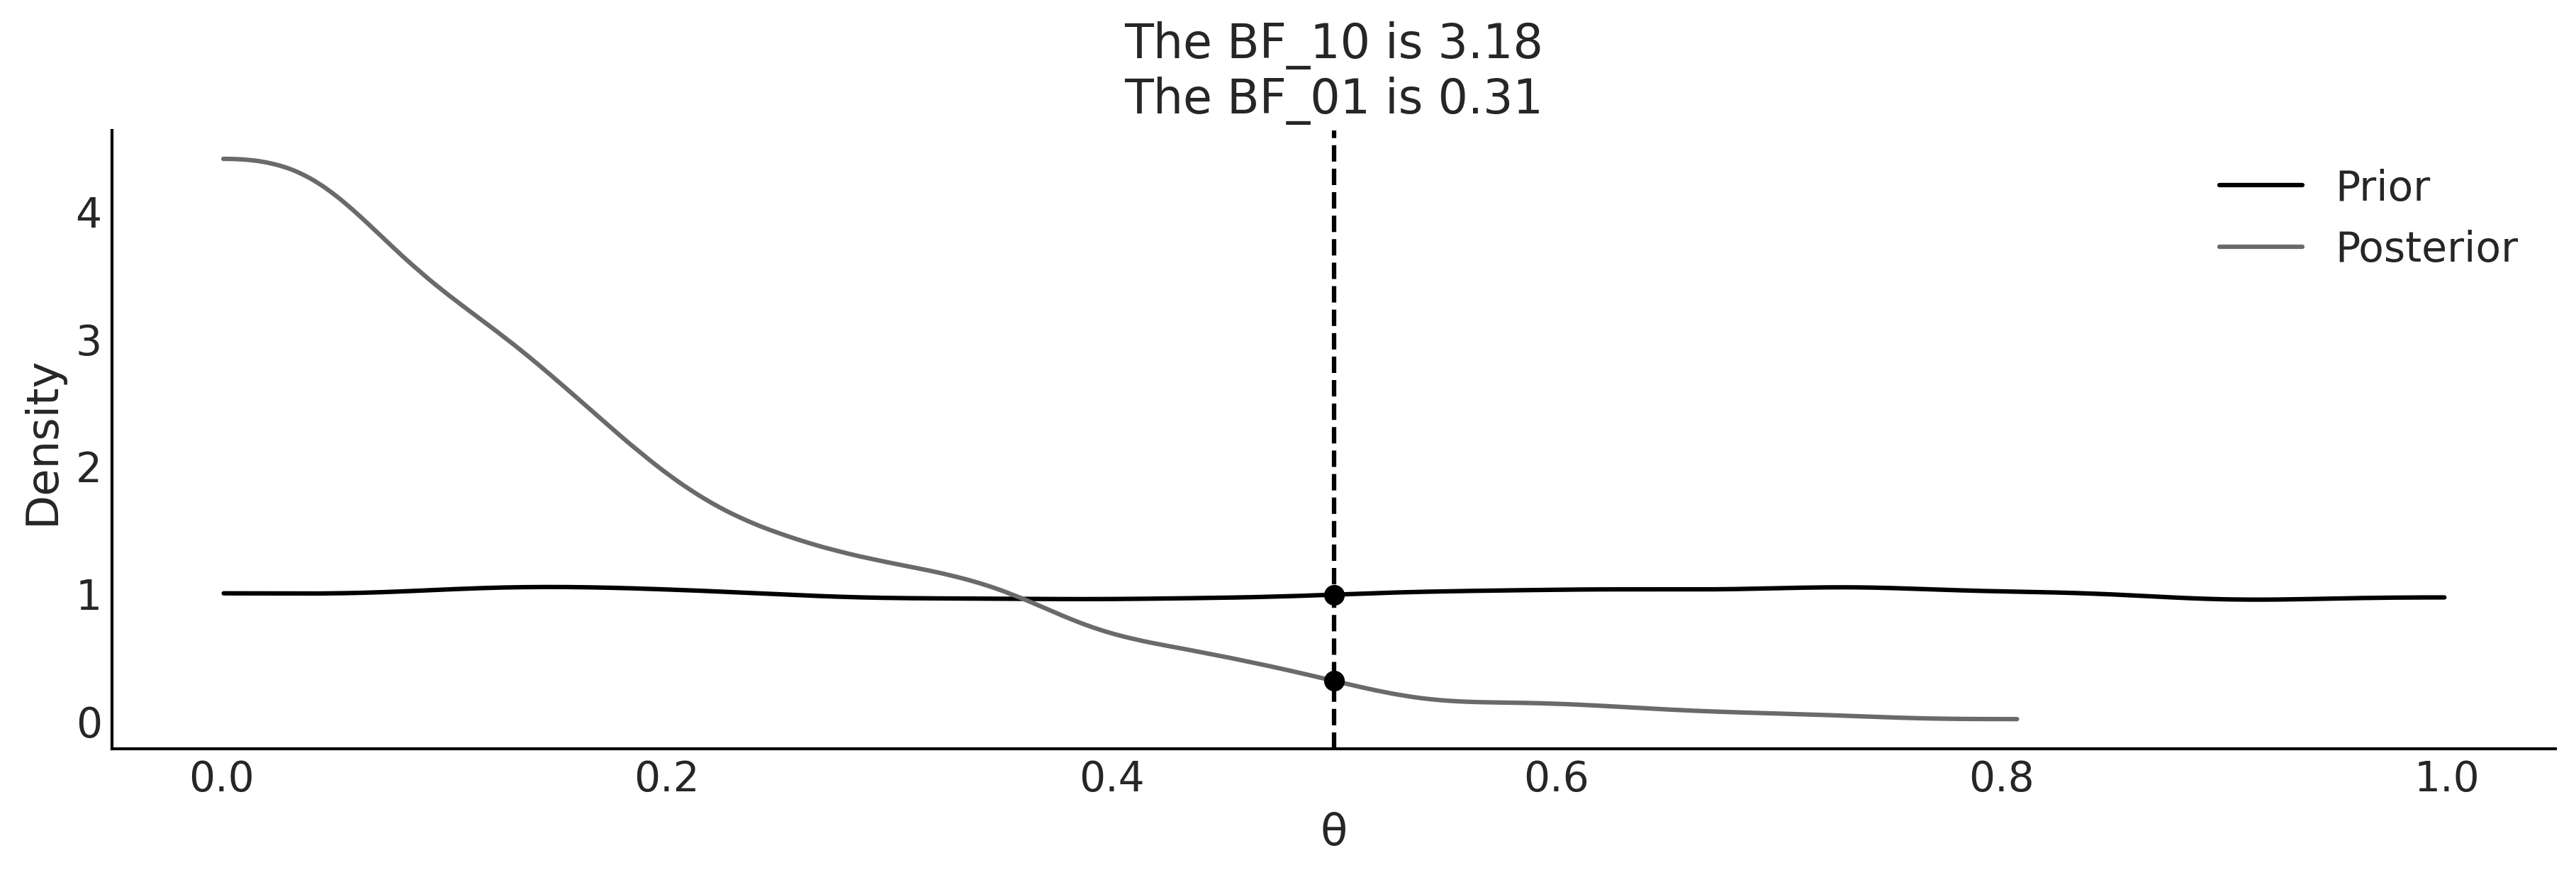

In [9]:
az.plot_bf(idata, var_name='θ', prior=np.random.uniform(0, 1, 10000), ref_val=0.5, figsize=(12, 4), colors=['C0', 'C1'])
plt.savefig('fig/idata_bf.png')

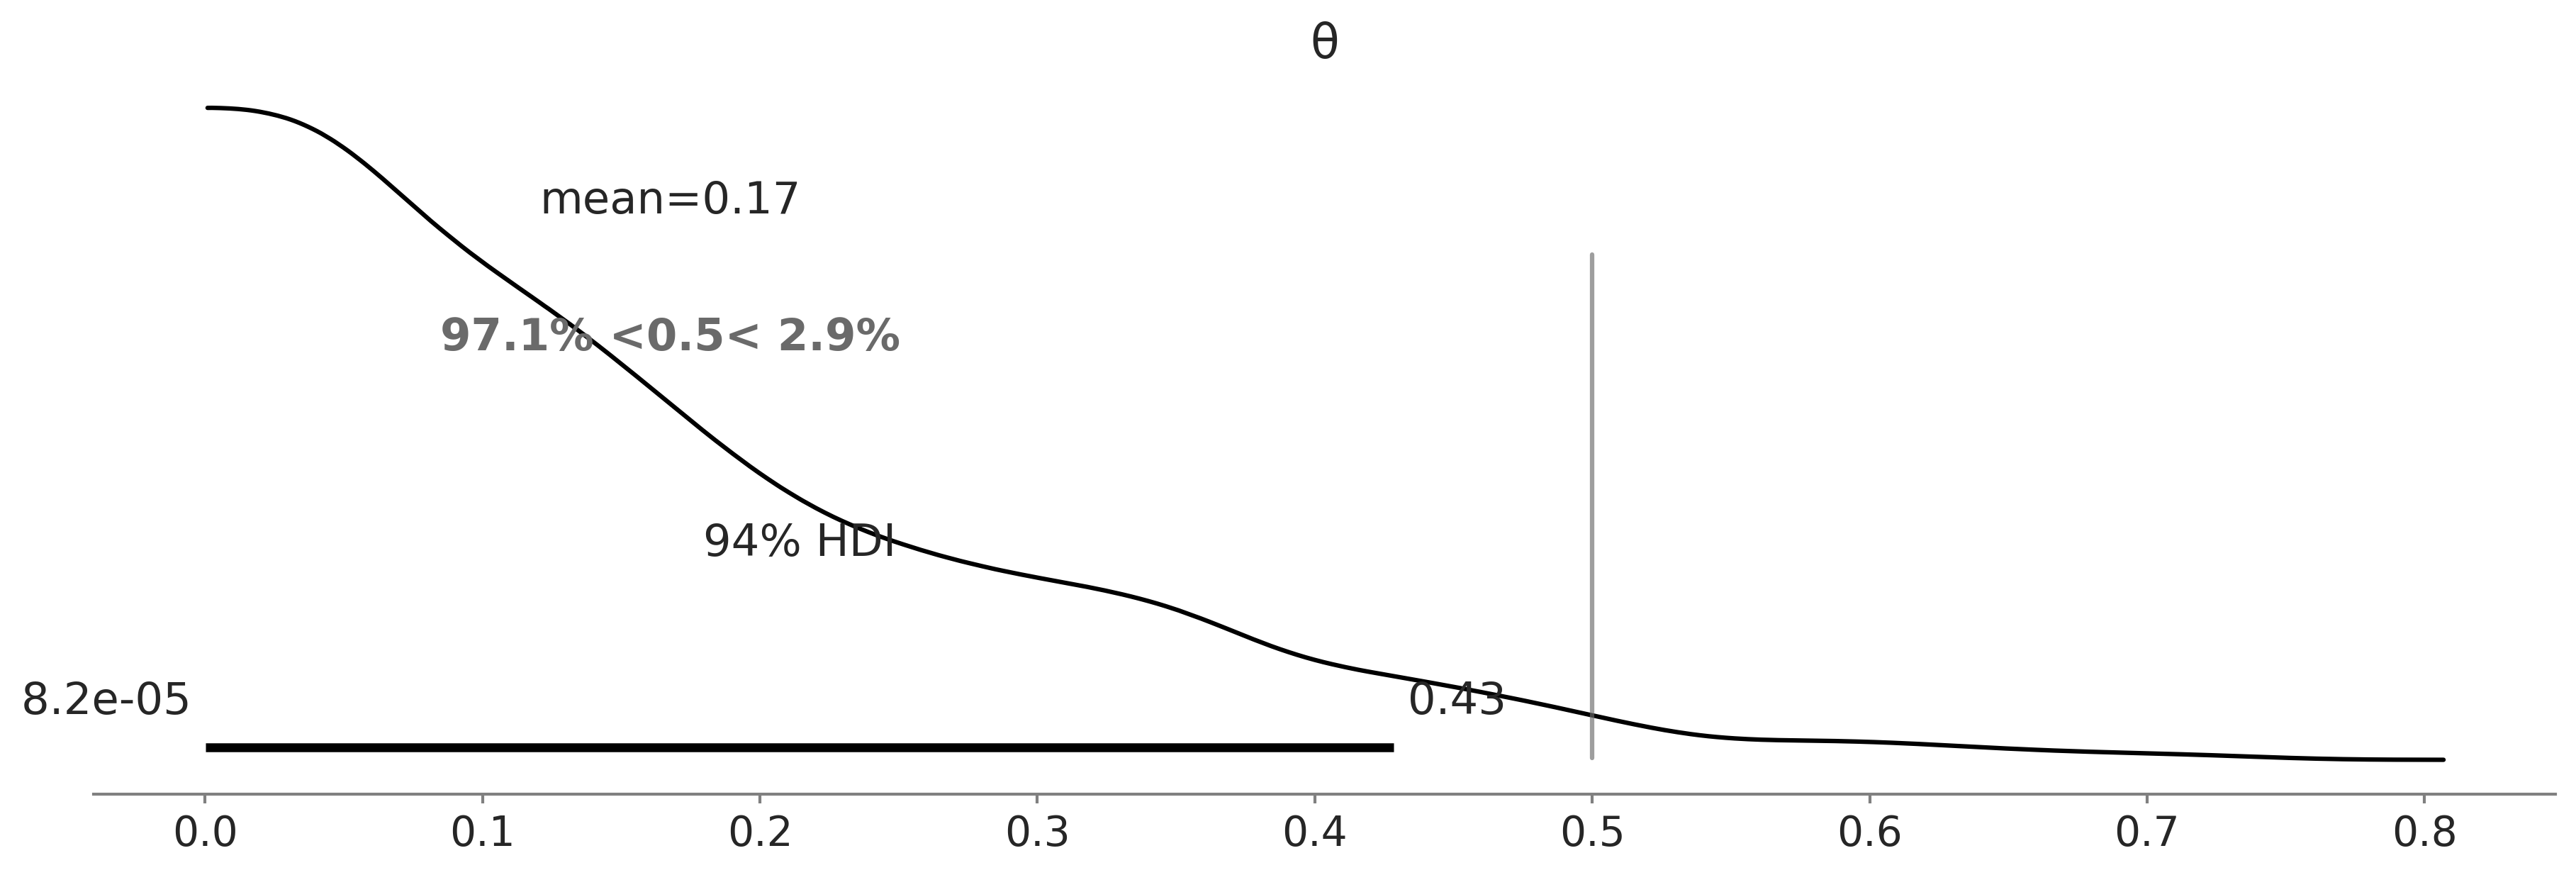

In [10]:
az.plot_posterior(idata, ref_val=0.5, figsize=(12, 4))
plt.savefig('fig/idata_posterior_ref.png')

In [11]:
grid = np.linspace(0, 1, 200)
θ_pos = idata.posterior['θ']
lossf_a = [np.mean(abs(i - θ_pos)) for i in grid]
lossf_b = [np.mean((i - θ_pos)**2) for i in grid]
np.argmin(lossf_a)

26

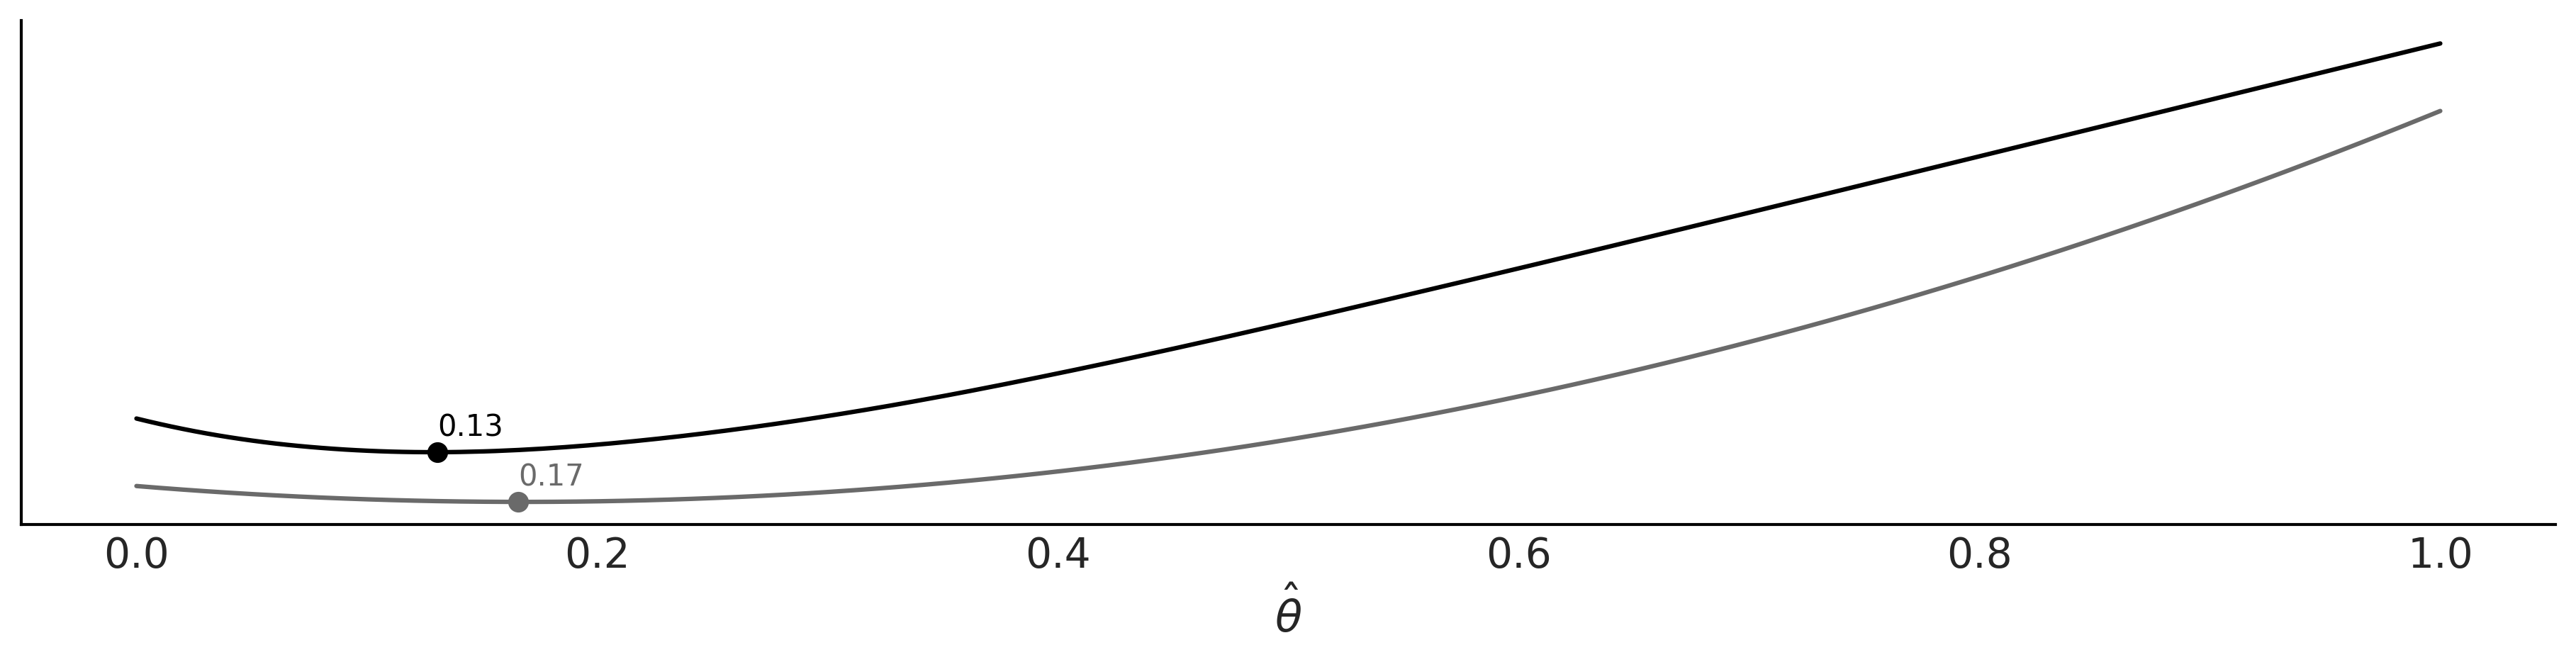

In [12]:
_, ax = plt.subplots(figsize=(12, 3))
for lossf, c in zip([lossf_a, lossf_b], ['C0', 'C1']):
    mini = np.argmin(lossf)
    ax.plot(grid, lossf, c)
    ax.plot(grid[mini], lossf[mini], 'o', color=c)
    ax.annotate('{:.2f}'.format(grid[mini]), (grid[mini], lossf[mini] + 0.03), color=c)

    ax.set_yticks([])
    ax.set_xlabel(r'$\hat \theta$')

plt.savefig('fig/idata_loss.png')

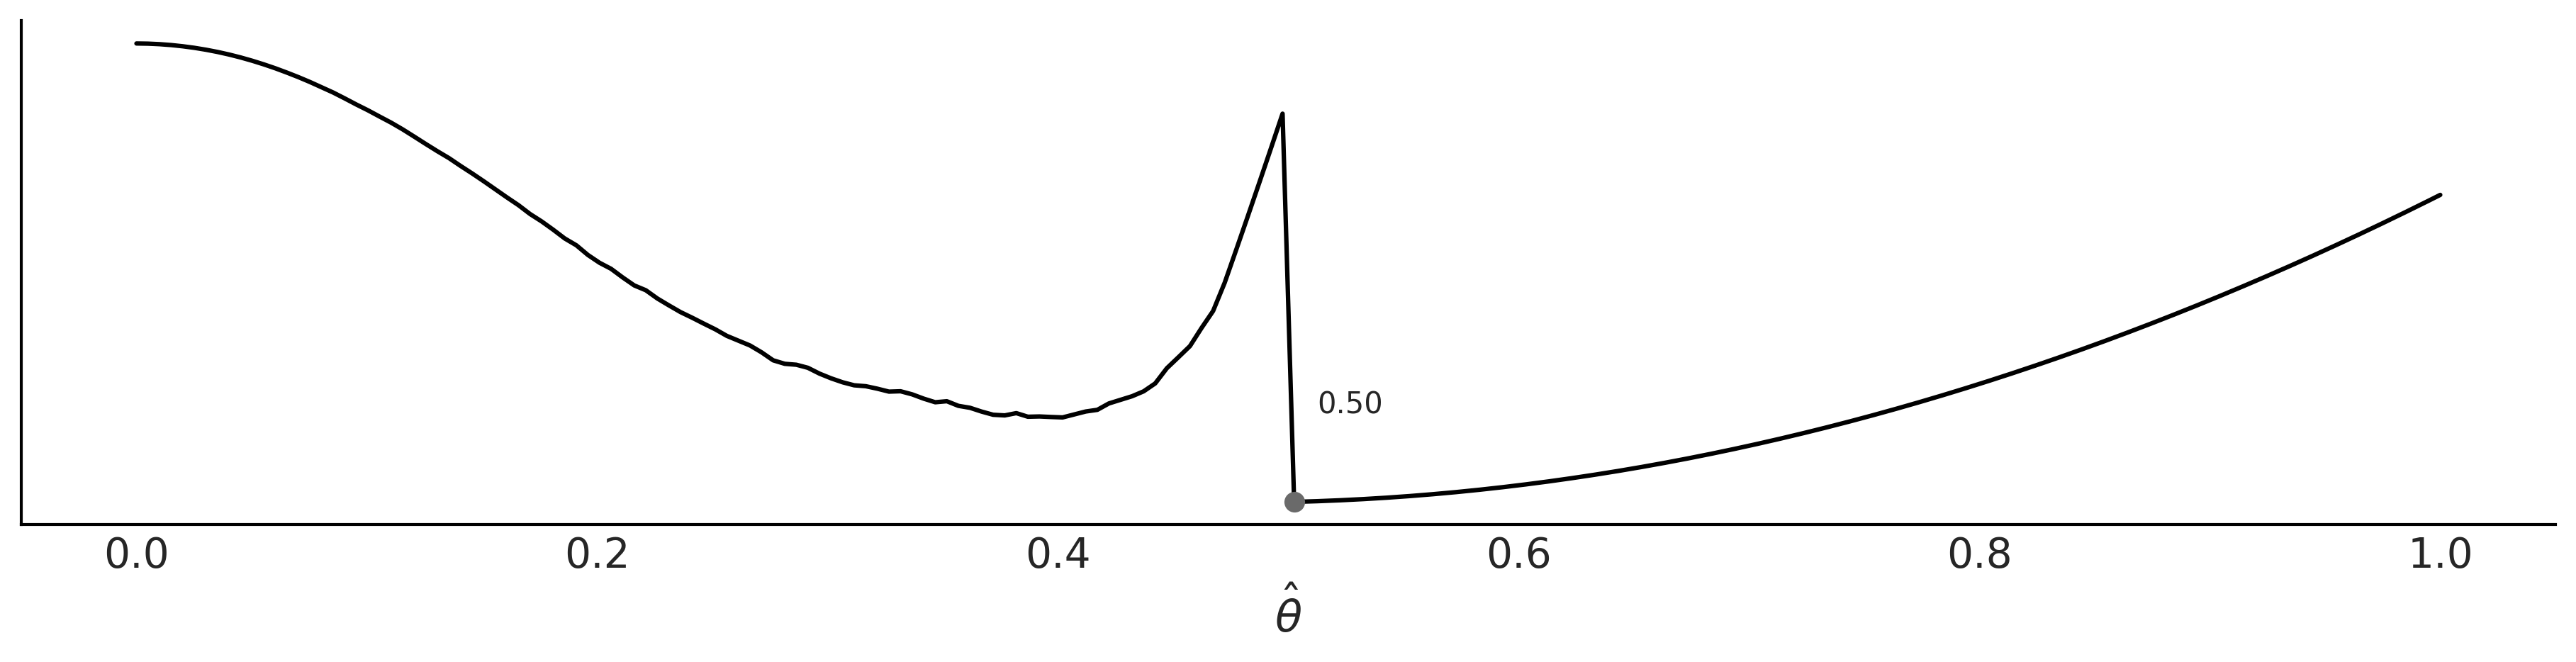

In [13]:
lossf = []
for i in grid:
    if i < 0.5:
        f = 1/np.median(θ_pos / np.abs(i**2 - θ_pos))
    else:
        f = np.mean((i - θ_pos)**2 + np.exp(-i)) - 0.25
    lossf.append(f)

mini = np.argmin(lossf)
_, ax = plt.subplots(figsize=(12, 3))
ax.plot(grid, lossf)
ax.plot(grid[mini], lossf[mini], 'o')
ax.annotate('{:.2f}'.format(grid[mini]), (grid[mini] + 0.01, lossf[mini] + 0.1))
ax.set_yticks([])
ax.set_xlabel(r'$\hat \theta$')

plt.savefig('fig/idata_loss2.png')

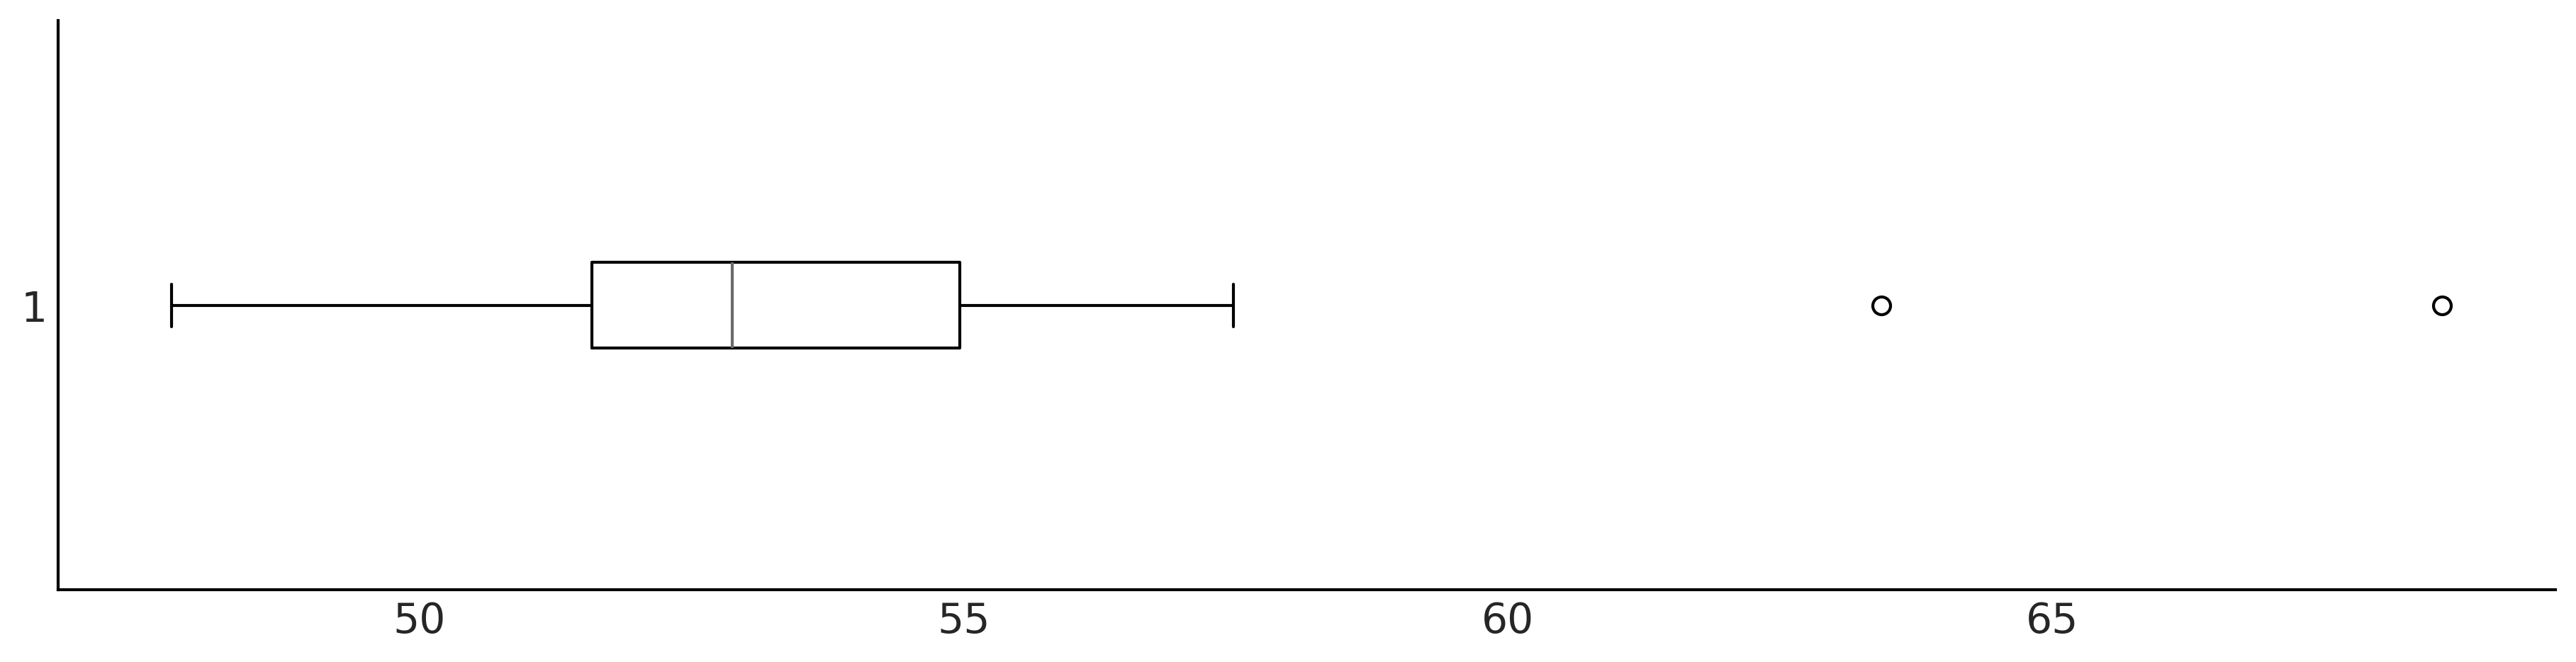

In [14]:
data = np.loadtxt('../code/data/chemical_shifts.csv')
_, ax = plt.subplots(figsize=(12, 3))
ax.boxplot(data, vert=False)
plt.savefig('fig/boxplot.png')

In [15]:
with pm.Model() as model_g:
    µ = pm.Uniform('µ', lower=40, upper=70)
    σ = pm.HalfNormal('σ', sigma=5)
    Y = pm.Normal('Y', mu=µ, sigma=σ, observed=data)
    idata_g = pm.sample(random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [µ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


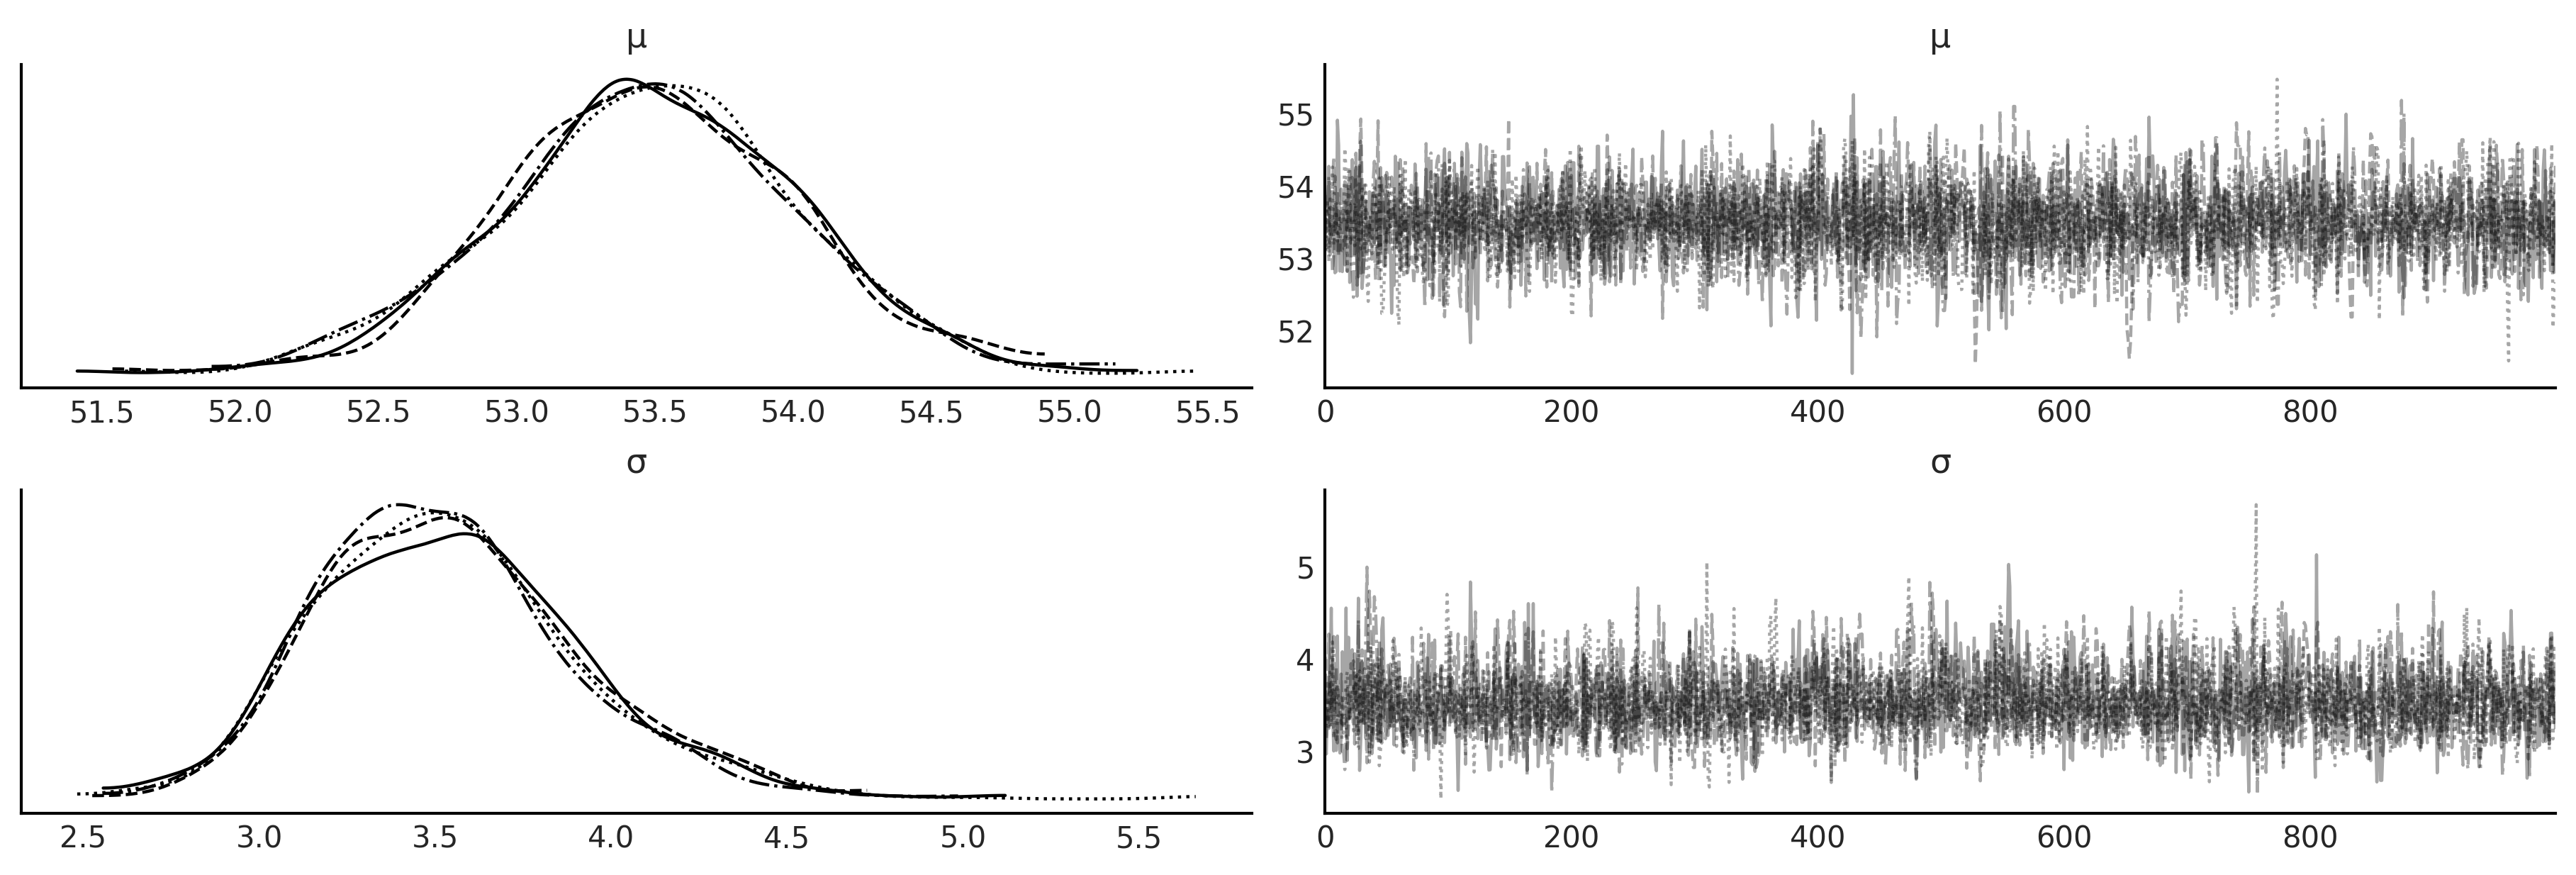

In [16]:
az.plot_trace(idata_g)
plt.savefig('fig/idata_g_trace.png')

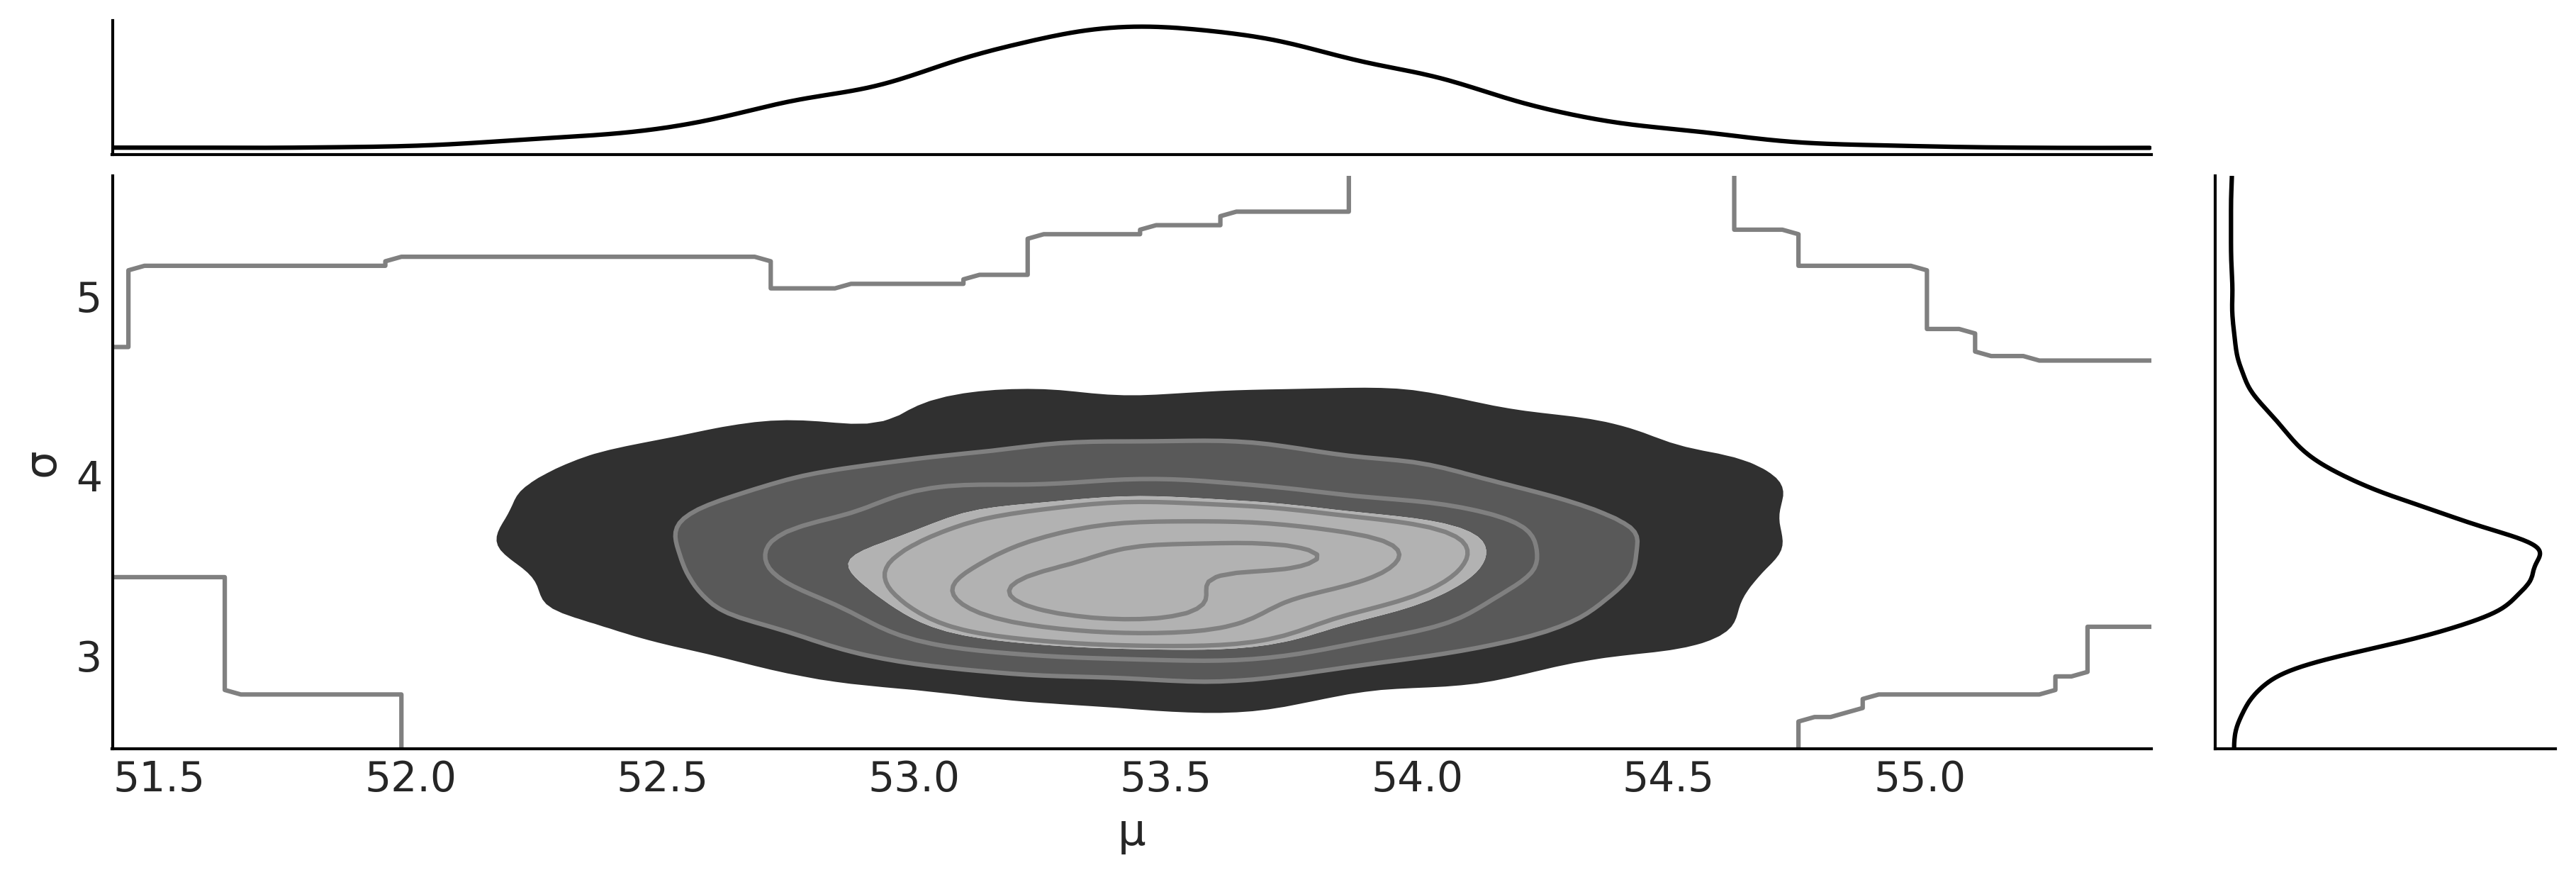

In [17]:
az.plot_pair(idata_g, kind='kde', marginals=True)
plt.savefig('fig/idata_g_pair.png')

In [18]:
az.summary(idata_g, kind='stats').round(2)

,mean,sd,hdi_3%,hdi_97%
µ,53.48,0.52,52.58,54.56
σ,3.53,0.36,2.94,4.30


In [19]:
pm.sample_posterior_predictive(idata_g, model=model_g, extend_inferencedata=True, random_seed=4591)

Sampling: [Y]


Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

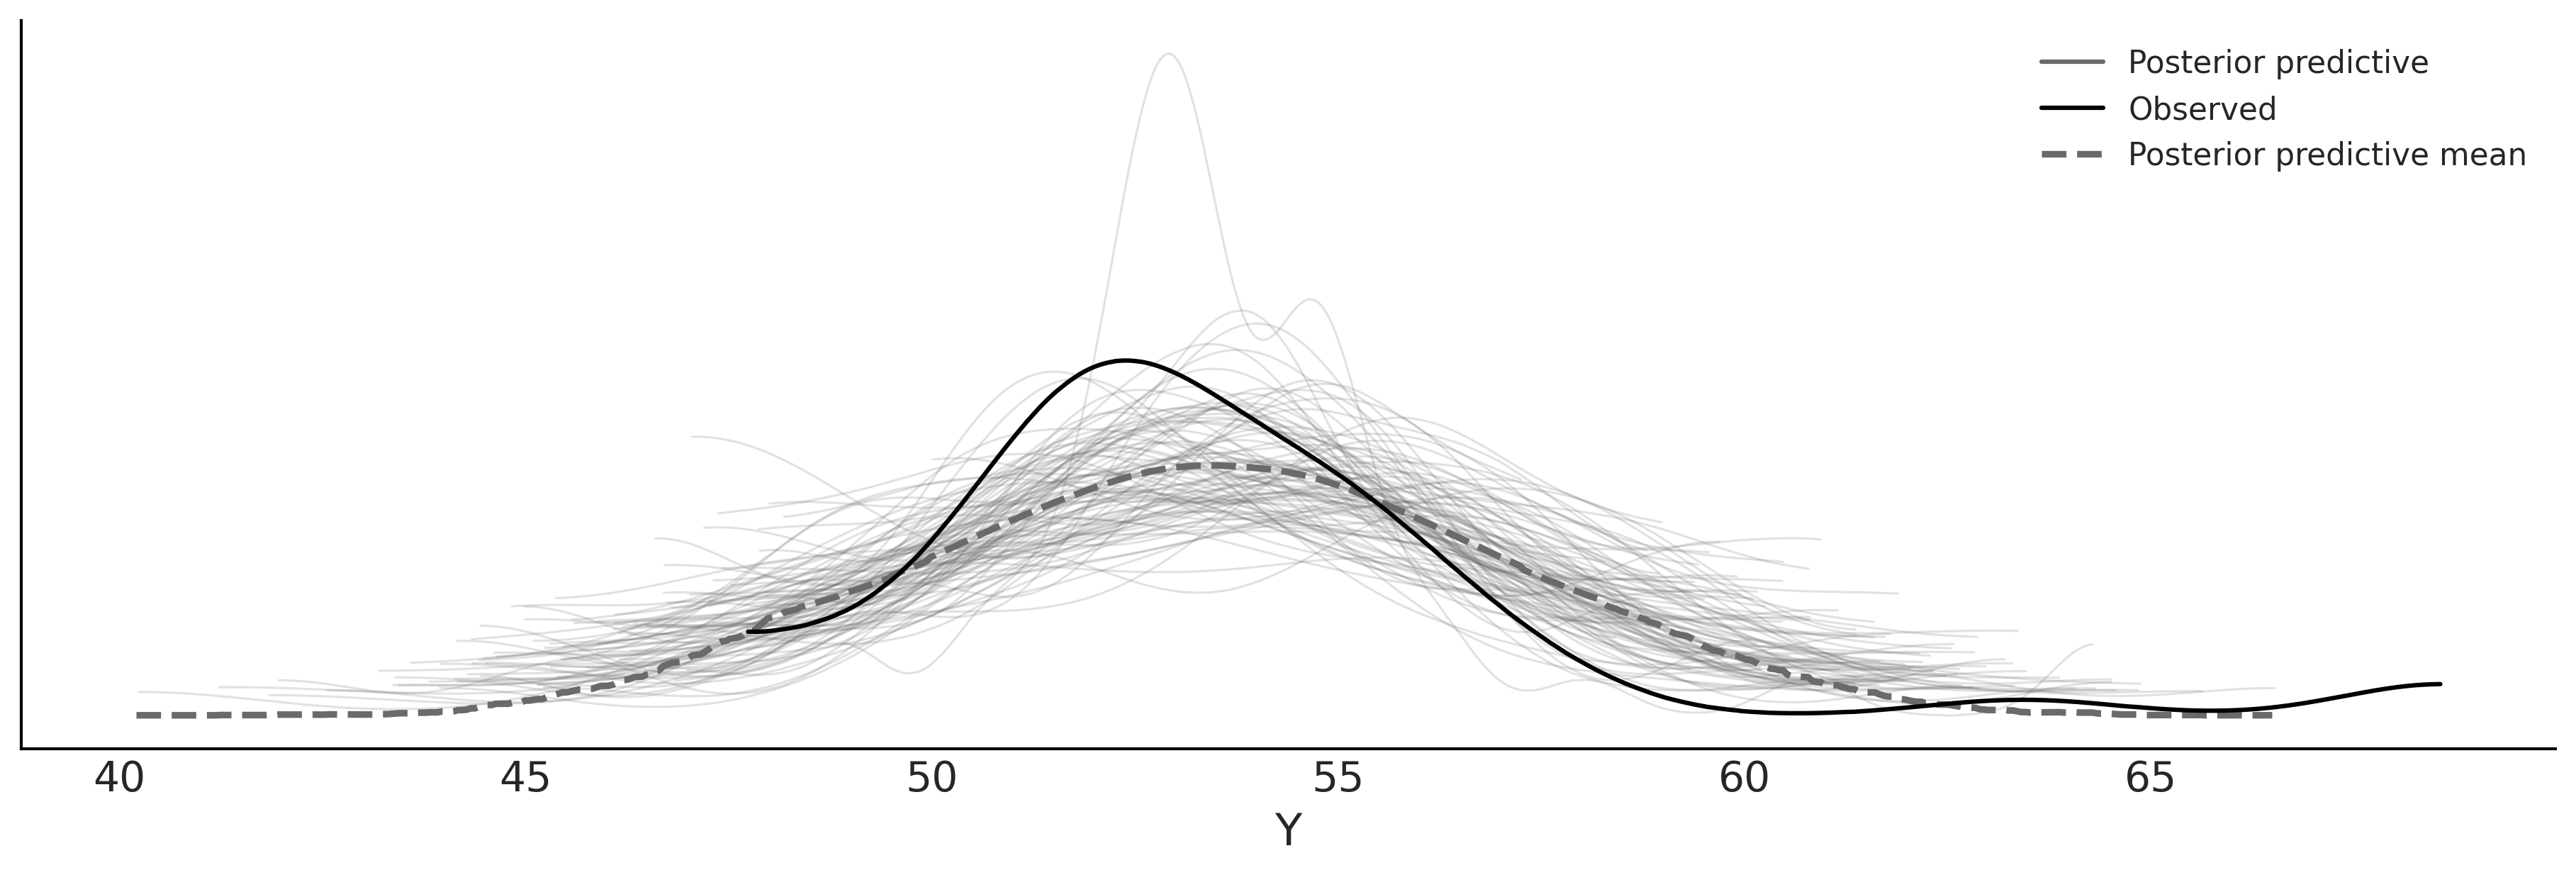

In [20]:
az.plot_ppc(idata_g, num_pp_samples=100, figsize=(12, 4), colors=['C1', 'C0', 'C1'])
plt.savefig('fig/idata_g_ppc.png')

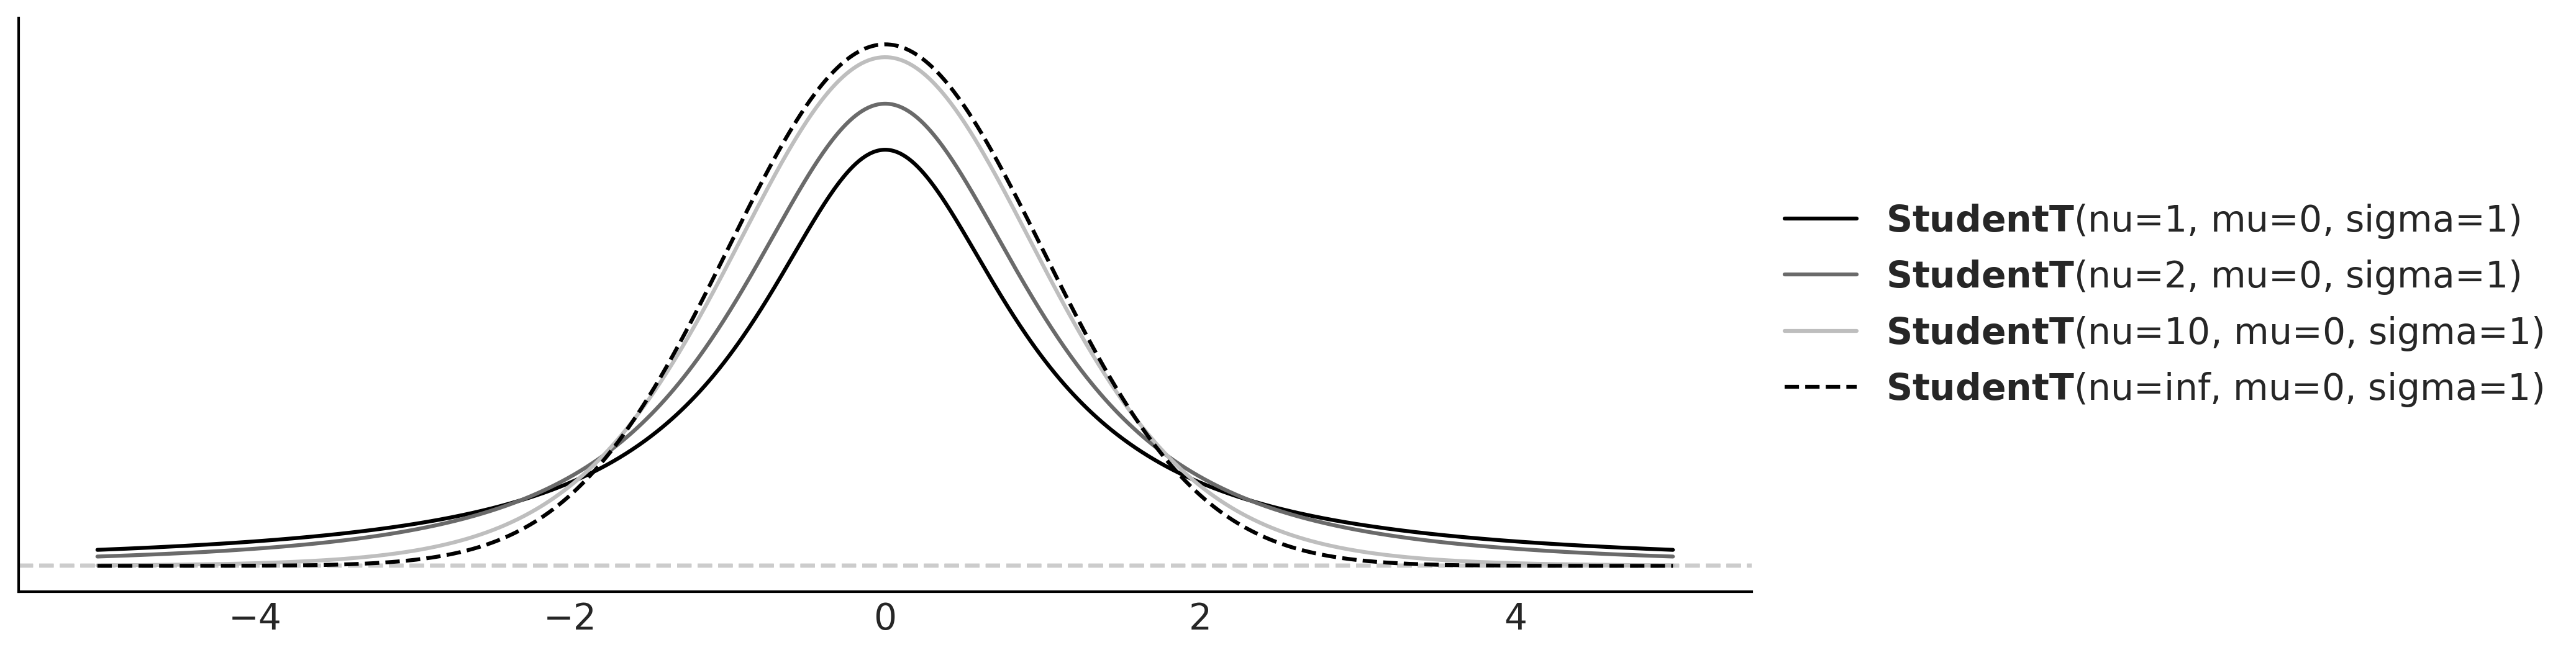

In [21]:
for nu in [1, 2, 10]:
    pz.StudentT(nu, 0, 1).plot_pdf(support=(-5, 5), figsize=(12, 4))

ax = pz.StudentT(np.inf, 0, 1).plot_pdf(support=(-5, 5), figsize=(12, 4), color='k')
ax.get_lines()[-1].set_linestyle('--')
pz.internal.plot_helper.side_legend(ax)
plt.savefig('fig/student_t.png')

In [22]:
with pm.Model() as model_t:
    µ = pm.Uniform('µ', lower=40, upper=70)
    σ = pm.HalfNormal('σ', sigma=10)
    v = pm.Exponential('v', 1/30)
    y = pm.StudentT('y', nu=v, mu=µ, sigma=σ, observed=data)
    idata_t = pm.sample(random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [µ, σ, v]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


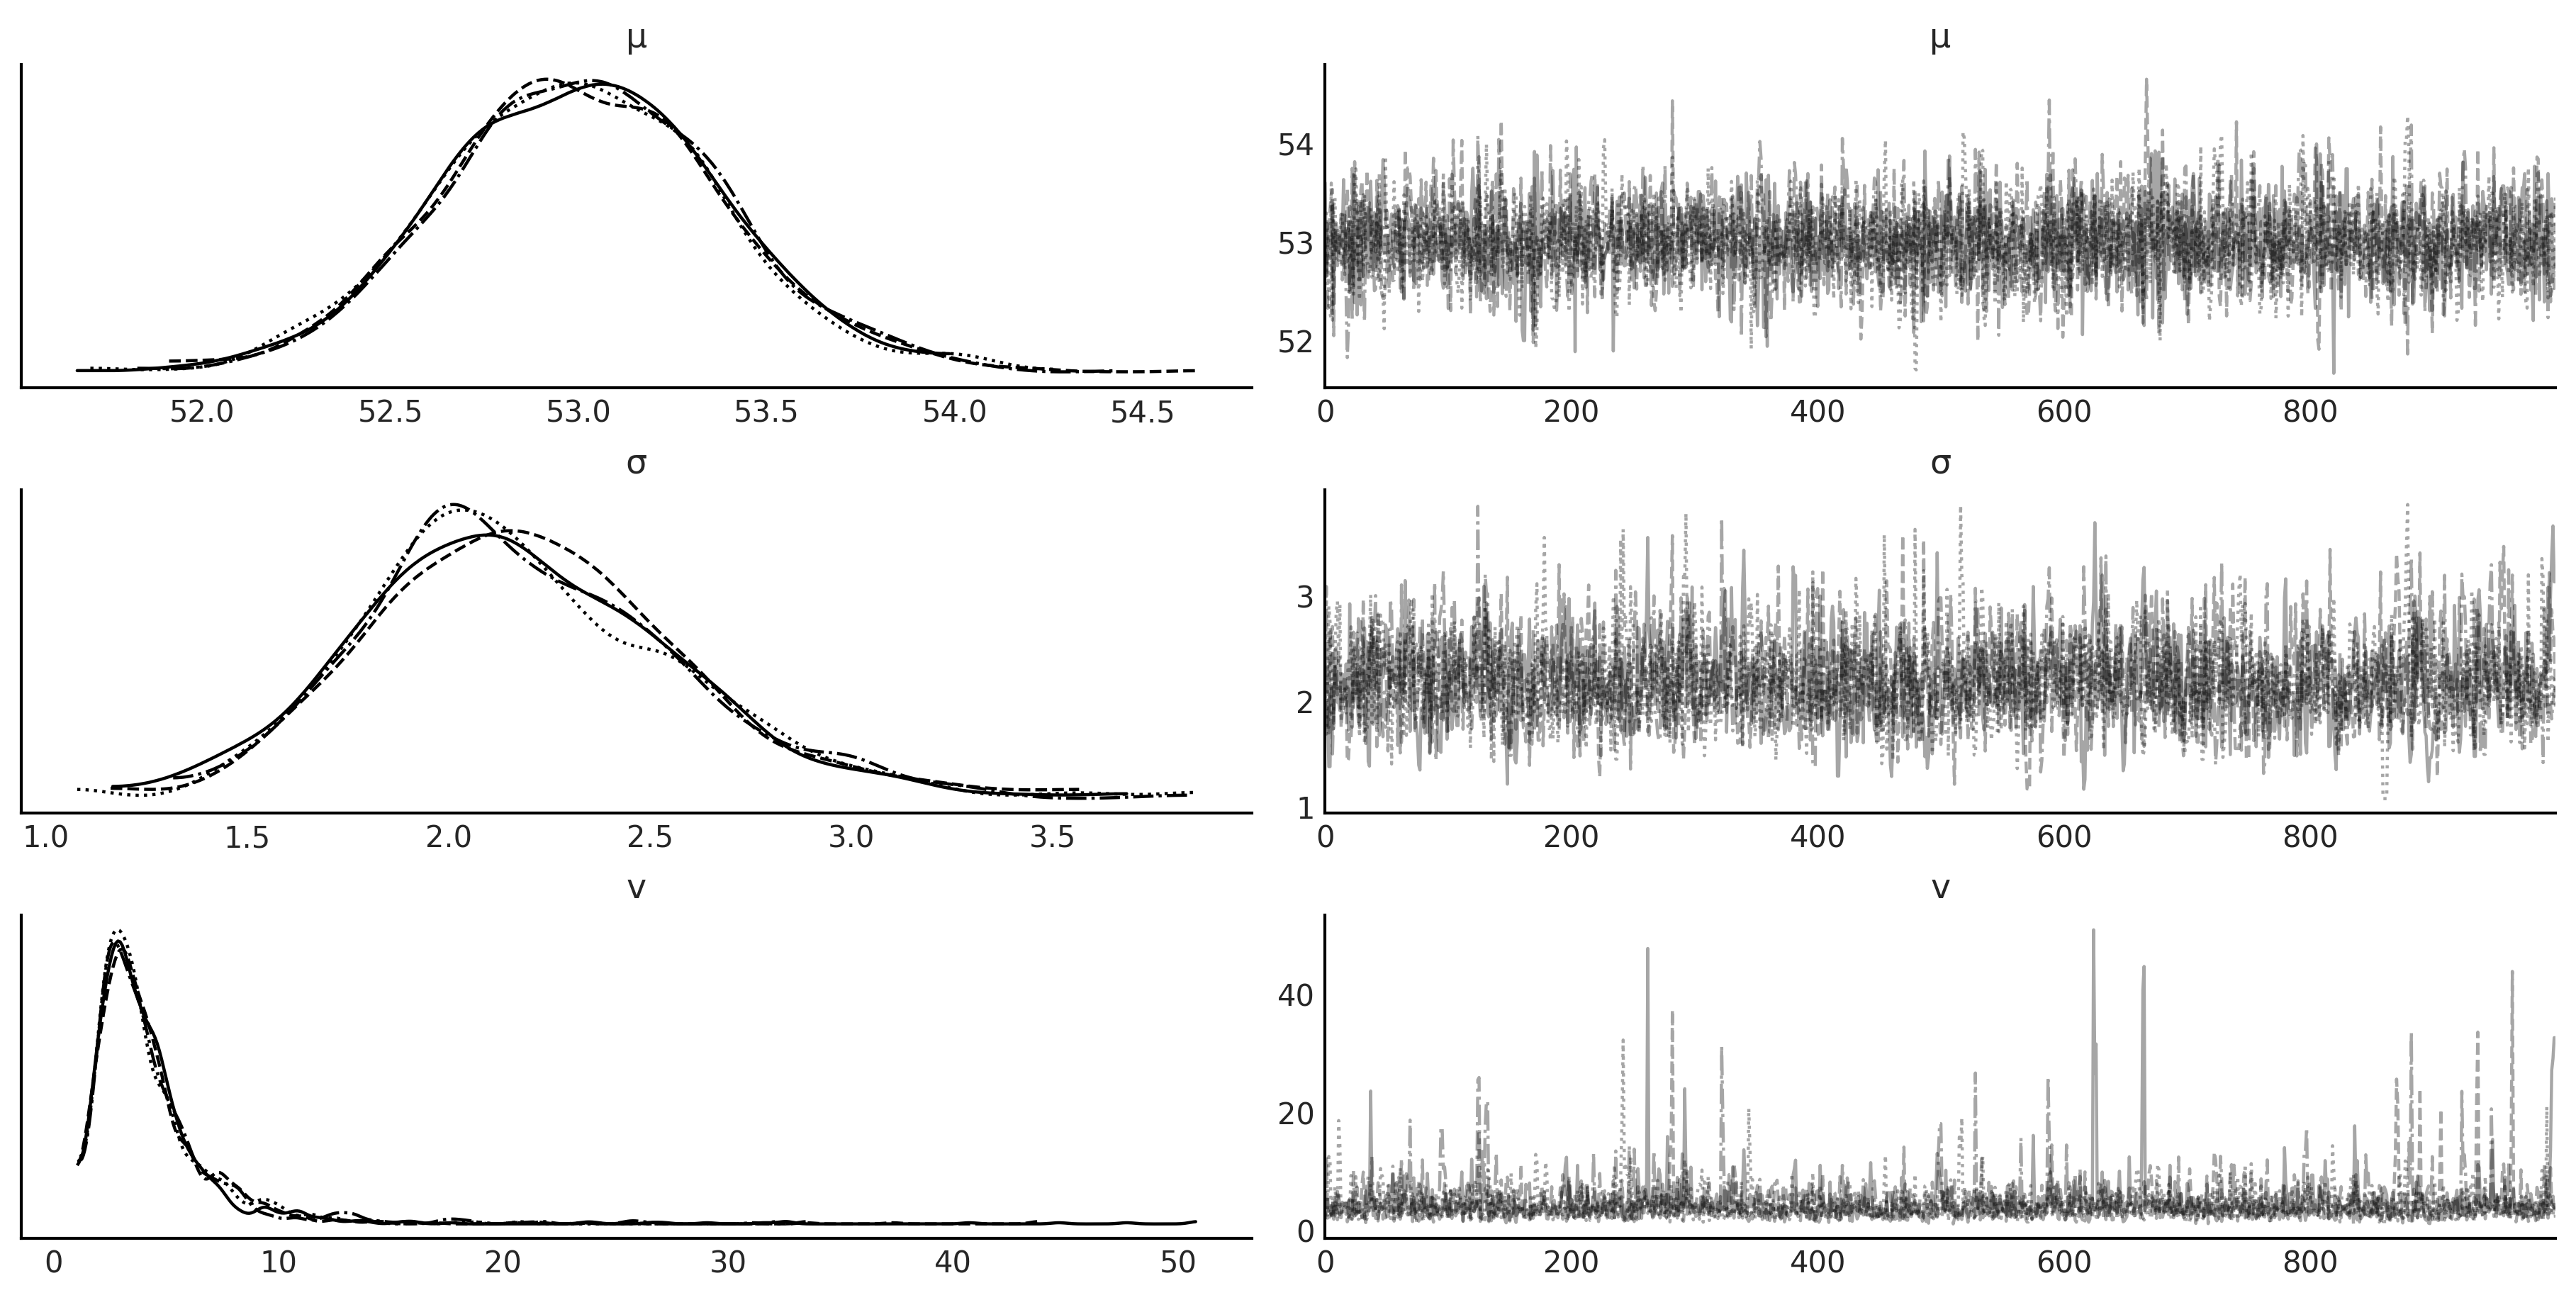

In [23]:
az.plot_trace(idata_t)
plt.savefig('fig/idata_t_trace.png')

In [24]:
az.summary(idata_t, kind='stats', round_to=2)

,mean,sd,hdi_3%,hdi_97%
µ,53.01,0.37,52.29,53.70
σ,2.18,0.39,1.45,2.90
v,4.45,3.35,1.24,8.98


Sampling: [y]


Output()

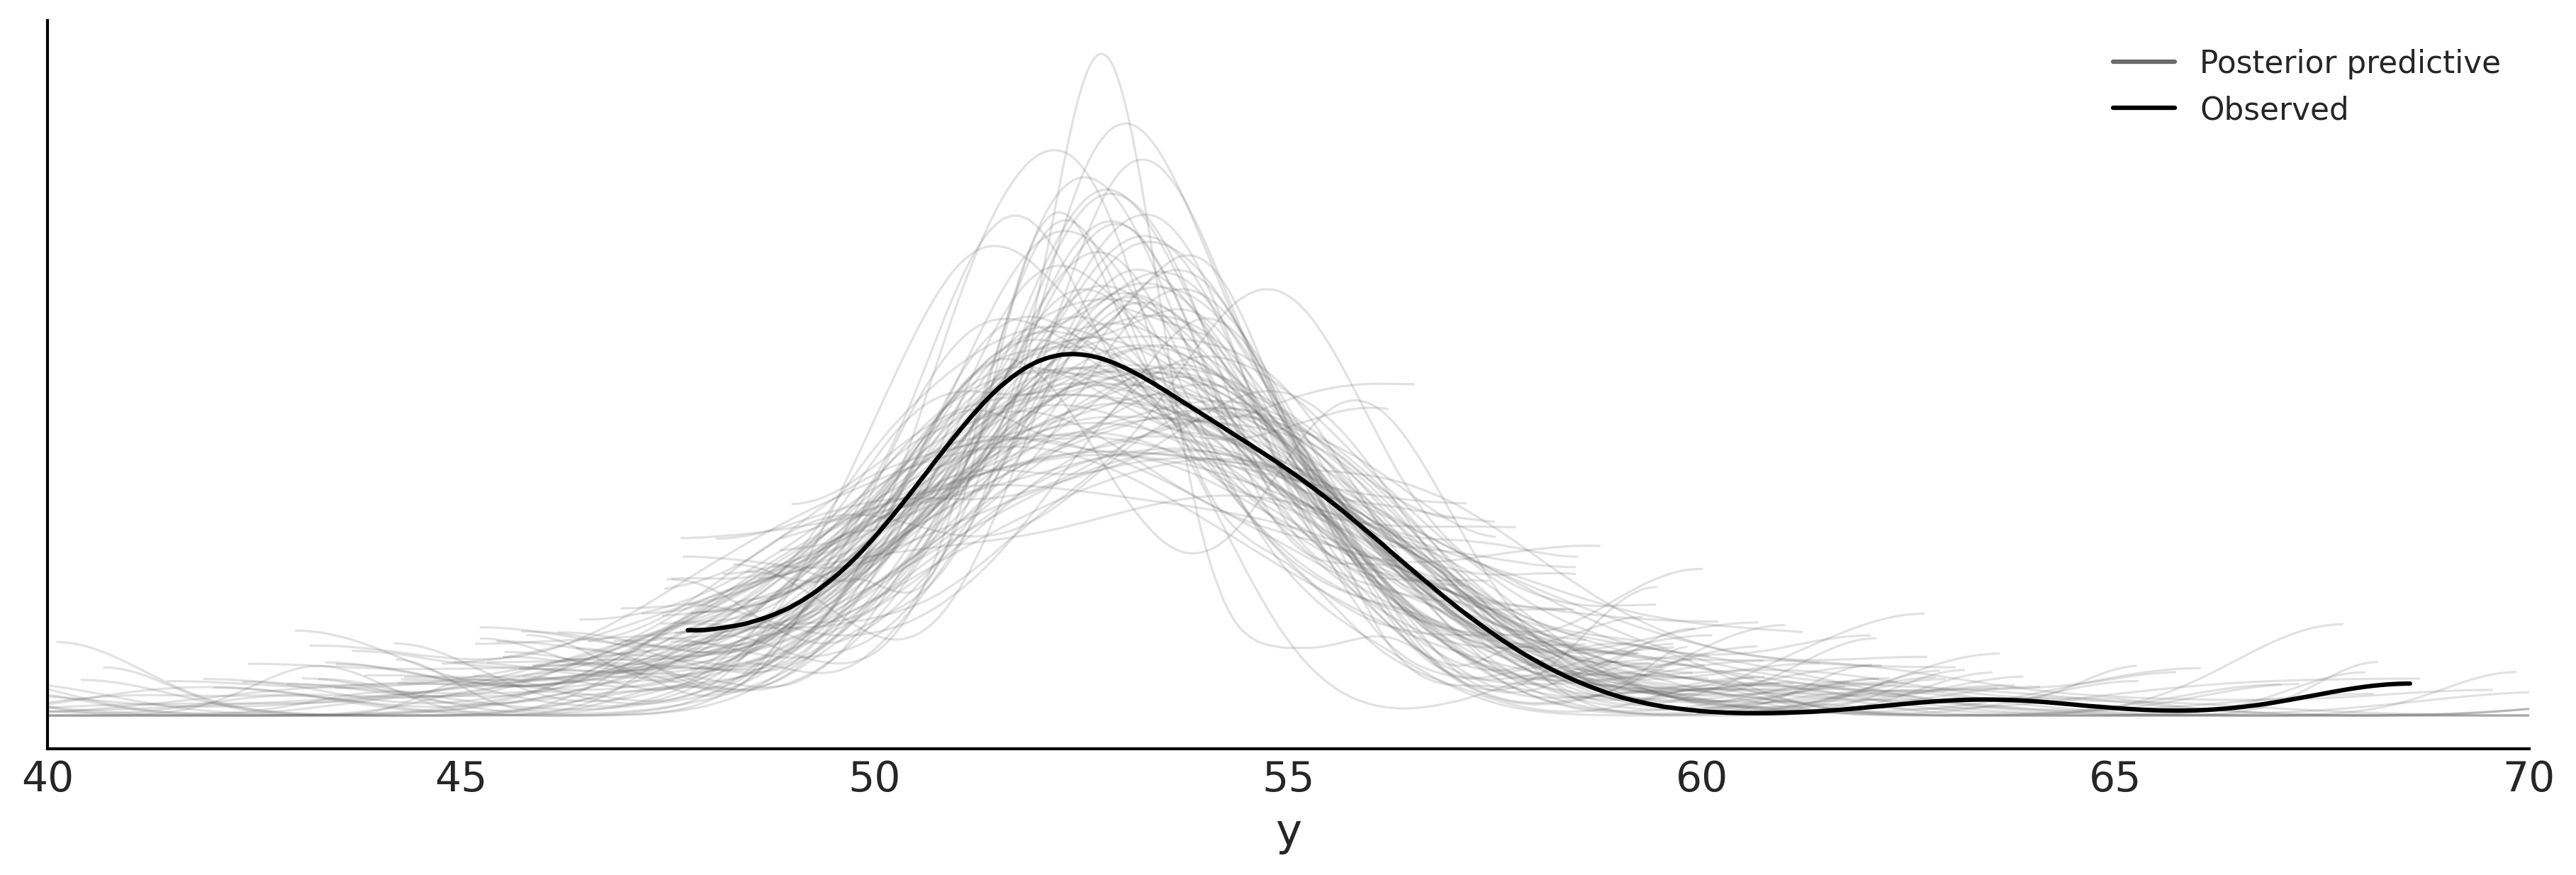

In [25]:
pm.sample_posterior_predictive(idata_t, model=model_t, extend_inferencedata=True, random_seed=123)
ax = az.plot_ppc(idata_t, figsize=(12, 4), num_pp_samples=100, mean=False, colors=['C1', 'C0', 'C1'])
ax.set_xlim(40, 70)
plt.savefig('fig/idata_t_ppc.png')

In [26]:
idata_g

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [27]:
posterior = idata_g.posterior

In [28]:
posterior.sel(draw=0, chain=[0, 2])

<xarray.Dataset> Size: 56B
Dimensions:  (chain: 2)
Coordinates:
  * chain    (chain) int64 16B 0 2
    draw     int64 8B 0
Data variables:
    µ        (chain) float64 16B 53.48 53.1
    σ        (chain) float64 16B 3.05 4.017
Attributes:
    created_at:                 2025-03-19T12:18:48.747425+00:00
    arviz_version:              0.20.0
    inference_library:          pymc
    inference_library_version:  5.19.1
    sampling_time:              0.7017168998718262
    tuning_steps:               1000

In [29]:
posterior.sel(draw=slice(0,100))

<xarray.Dataset> Size: 7kB
Dimensions:  (chain: 4, draw: 101)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 808B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99 100
Data variables:
    µ        (chain, draw) float64 3kB 53.48 53.84 53.59 ... 54.01 52.86 52.74
    σ        (chain, draw) float64 3kB 3.05 2.966 3.73 ... 3.388 3.573 3.466
Attributes:
    created_at:                 2025-03-19T12:18:48.747425+00:00
    arviz_version:              0.20.0
    inference_library:          pymc
    inference_library_version:  5.19.1
    sampling_time:              0.7017168998718262
    tuning_steps:               1000

In [30]:
posterior.mean()

<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    µ        float64 8B 53.48
    σ        float64 8B 3.534

In [31]:
stacked = az.extract(idata_g)

In [39]:
tips = pd.read_csv('../code/data/tips.csv')
tips.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [41]:
tips.pivot(columns='day', values='tip')

day,Fri,Sat,Sun,Thur
0,NaN,NaN,1.01,NaN
1,NaN,NaN,1.66,NaN
2,NaN,NaN,3.50,NaN
3,NaN,NaN,3.31,NaN
4,NaN,NaN,3.61,NaN
...,...,...,...,...
239,NaN,5.92,NaN,NaN
240,NaN,2.00,NaN,NaN
241,NaN,2.00,NaN,NaN
242,NaN,1.75,NaN,NaN


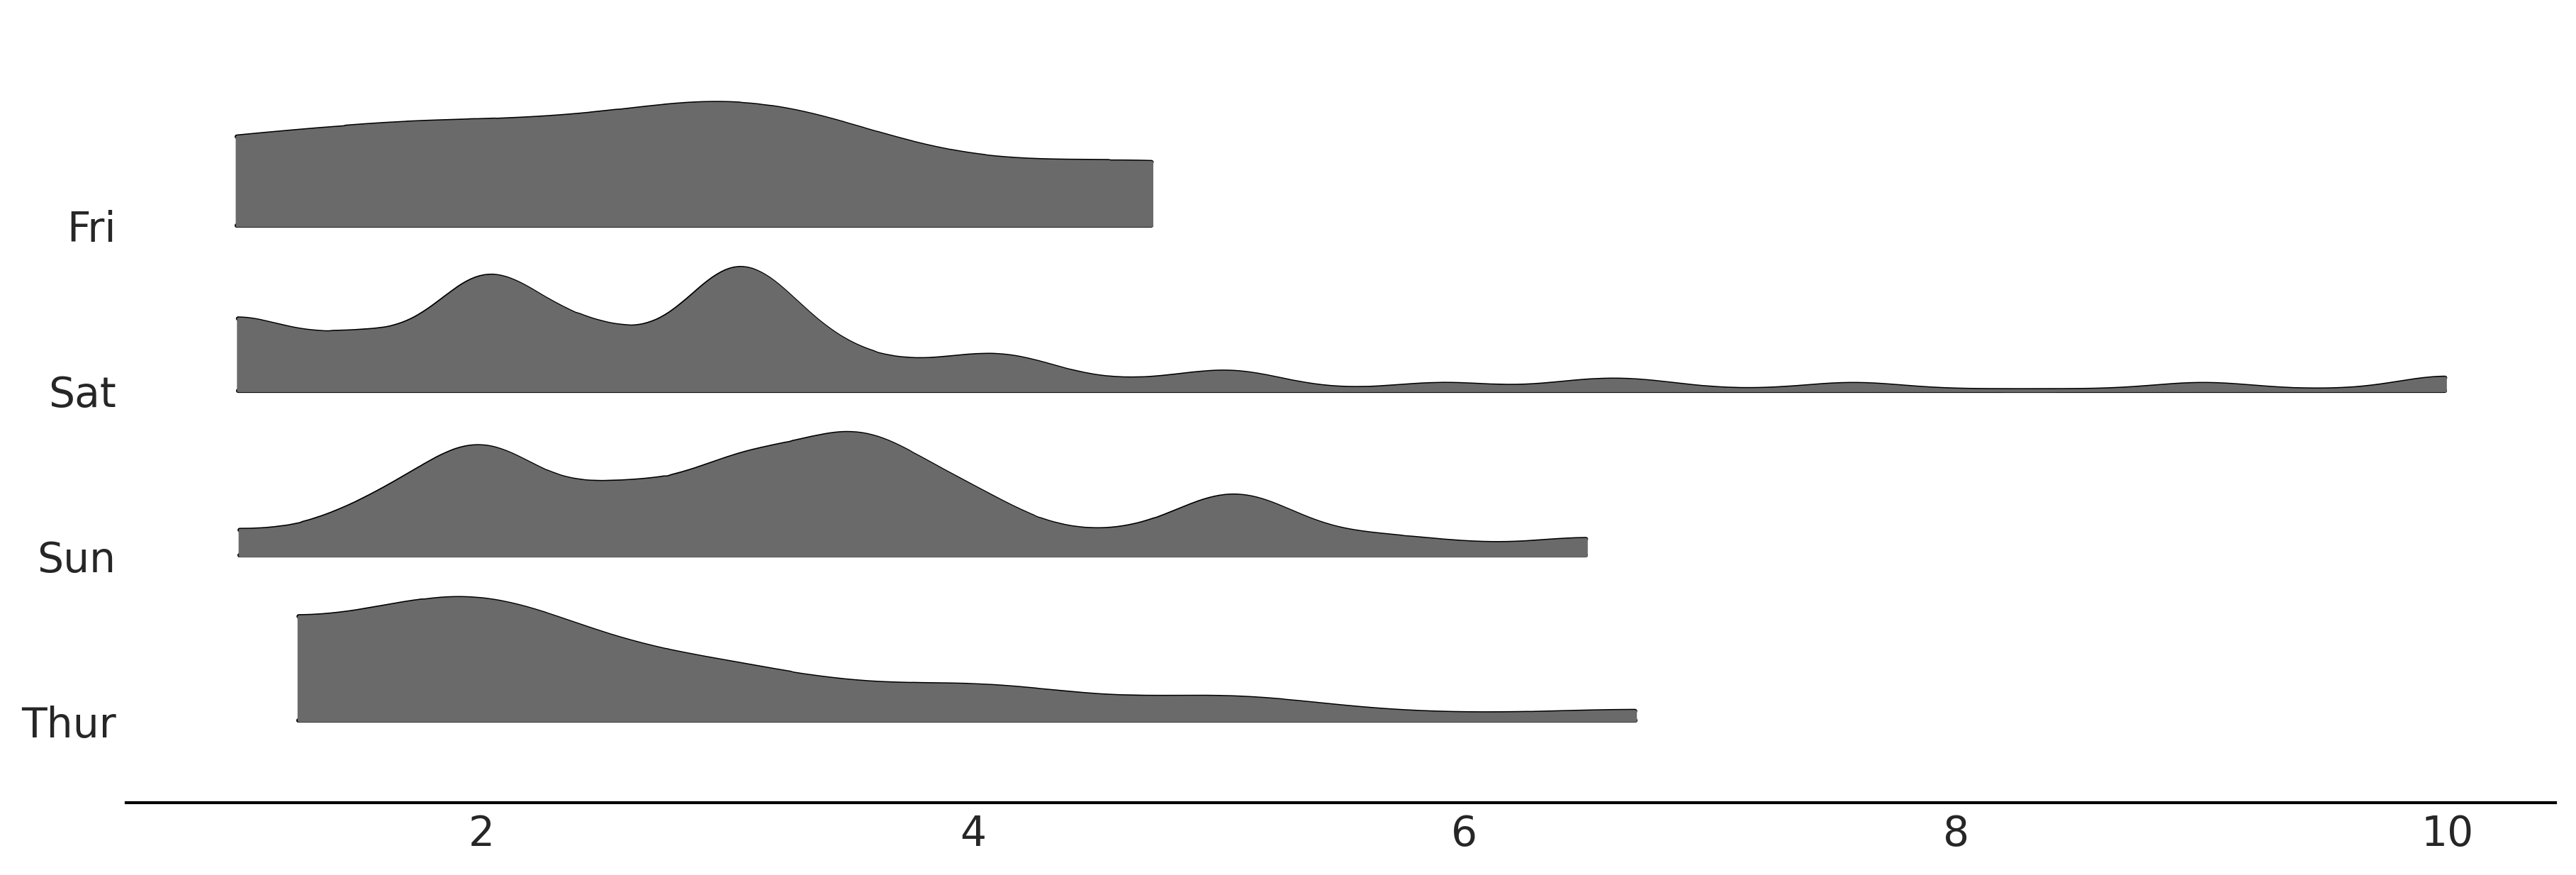

In [42]:
az.plot_forest(tips.pivot(columns='day', values='tip').to_dict('list'),
               kind='ridgeplot',
               hdi_prob=1,
               colors='C1',
               figsize=(12, 4))
plt.savefig('fig/tips_ridgeplot.png')

In [43]:
categories = np.array(['Thur', 'Fri', 'Sat', 'Sun'])

tip = tips['tip'].values
idx = pd.Categorical(tips['day'], categories=categories).codes
idx

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0], dtype=int8)

In [44]:
coords = {'days': categories, 'days_flat':categories[idx]}

with pm.Model(coords=coords) as comparing_groups:
    μ = pm.HalfNormal('μ', sigma=5, dims='days')
    σ = pm.HalfNormal('σ', sigma=1, dims='days')

    y = pm.Gamma('y', mu=μ[idx], sigma=σ[idx], observed=tip, dims='days_flat')

    idata_cg = pm.sample(random_seed=4591)
    idata_cg.extend(pm.sample_posterior_predictive(idata_cg, random_seed=4591))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [y]


Output()

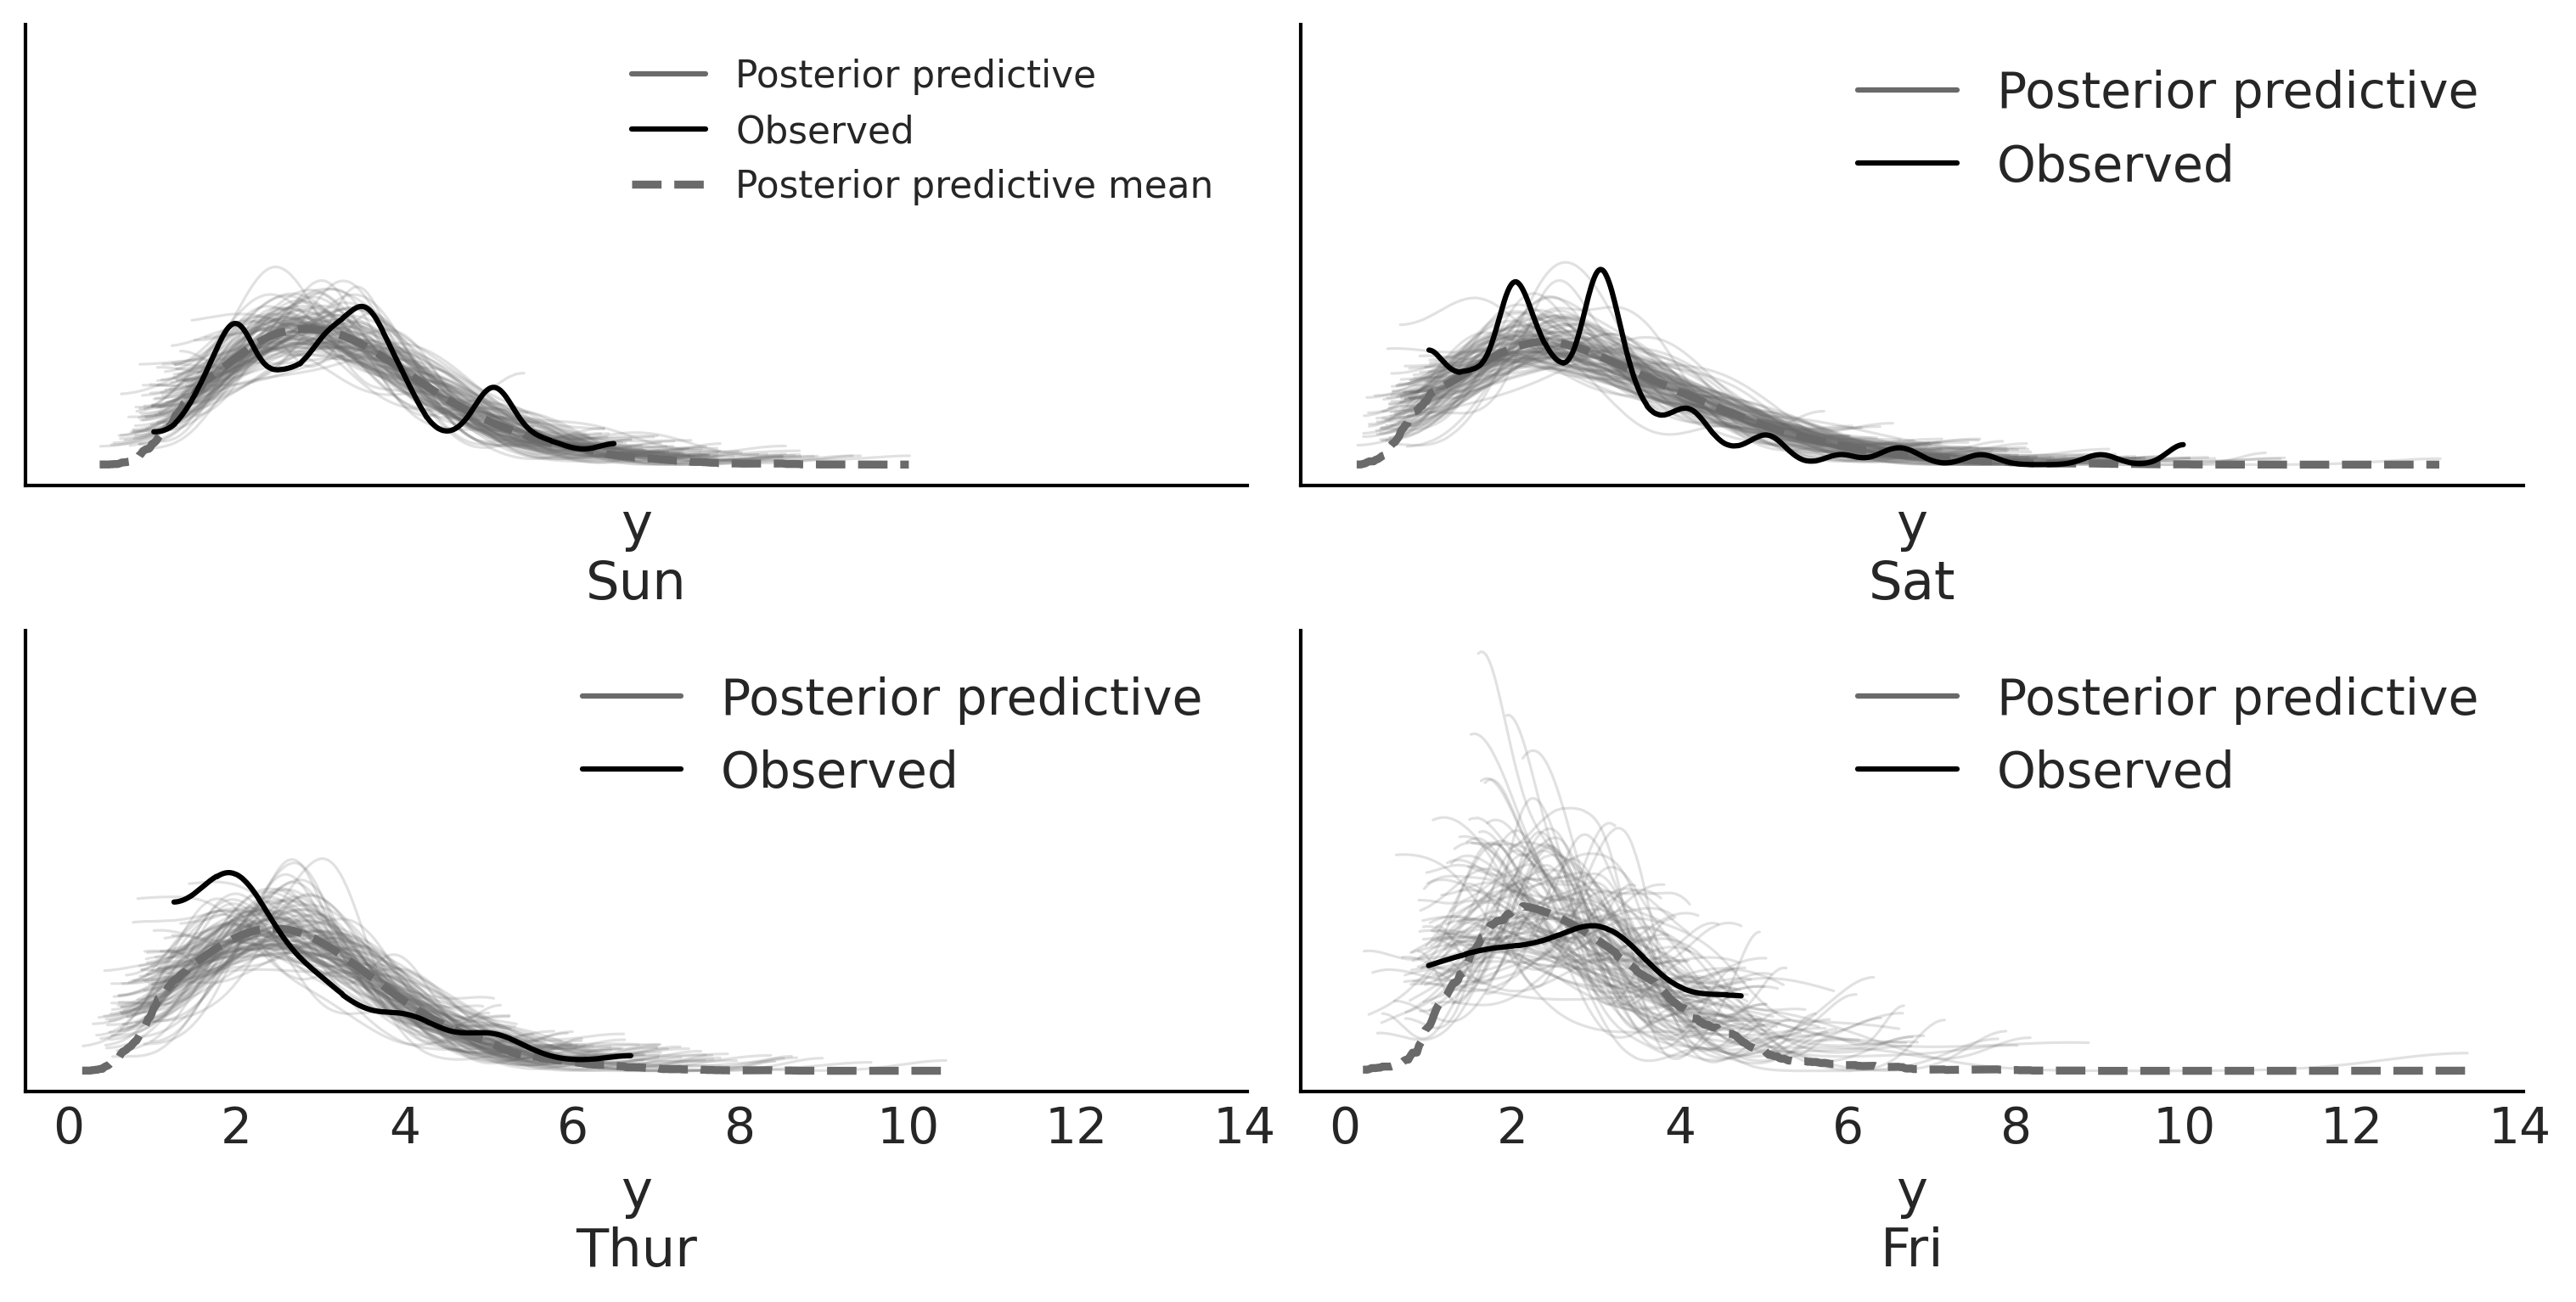

In [45]:
_, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=True)

az.plot_ppc(idata_cg, num_pp_samples=100,
            colors=['C1', 'C0', 'C1'],
            coords={'days_flat':[categories]}, flatten=[], ax=axes)
plt.savefig('fig/ppc_tips.png')